# DEAP Emotion Recognition — Comparative Analysis

This notebook runs a head-to-head comparison of **two feature/modeling paradigms** for
binary emotion classification on all **four DEAP label dimensions** — valence, arousal,
dominance, and liking — on the [DEAP dataset](https://www.eecs.qmul.ac.uk/mmv/datasets/deap/)
(`data_preprocessed_python`, 32 subjects × 40 trials × 32 EEG channels @128 Hz).

**Track A — Differential Entropy (DE) features → classical ML**
32 channels × 4 bands (θ, α, β, γ) = **128 features per window**, fed to:
`Logistic Regression, k-NN, Random Forest, SVM-RBF, XGBoost, MLP`.

**Track B — Raw baseline-normalized windows → deep learning**
Raw `(32 channels × window samples)` EEG, baseline-subtracted and per-window standardized, fed to:
`ShallowConvNet, EEGNet, CNN-LSTM, TSception`.

Both tracks share the same windowing scheme and the same subject-independent evaluation
protocol so their scores are directly comparable. Deep models are trained on **GPU (CUDA)**
if available, with automatic mixed precision for speed.

**Evaluation protocol**
- Track A (fast, classical models): 5-fold **GroupKFold** cross-validation, grouped by subject
  (subject-independent), mean ± std reported.
- Track B (expensive, deep models): a single subject-independent **train / val / test** split
  (subjects never overlap across splits), with early stopping on validation loss.

> Set `QUICK_RUN = True` in the config cell to smoke-test the whole pipeline on a handful of
> subjects / epochs before committing to a full run. With 4 label dimensions instead of 2, the
> deep-learning track now trains **16 models** (4 architectures × 4 tasks) — roughly double the
> runtime of a valence/arousal-only run.

> **Check §4 (class balance) before trusting any accuracy number.** DEAP's binary labels
> (rating `> 5`) can be skewed toward one class per dimension, which lets a model that always
> predicts the majority class look deceptively good on raw accuracy — treat ROC-AUC and F1 as
> the more trustworthy signals across all four tasks.


In [1]:

import os, sys, time, pickle, warnings, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, sosfiltfilt

from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix

from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
XGB_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# Fixed categorical palette, one color per model, reused consistently across every plot.
MODEL_ORDER = ["LogisticRegression", "kNN", "RandomForest", "SVM-RBF", "XGBoost", "MLP",
               "ShallowConvNet", "EEGNet", "CNN-LSTM", "TSception"]
PALETTE = dict(zip(MODEL_ORDER, sns.color_palette("colorblind", len(MODEL_ORDER))))

# DEAP labels array columns, in order: [valence, arousal, dominance, liking]
LABEL_COLUMNS = {"valence": 0, "arousal": 1, "dominance": 2, "liking": 3}
TASK_ORDER = list(LABEL_COLUMNS.keys())


Torch: 2.6.0+cu124 | CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti


## 1. Configuration & paths

In [2]:

# ----- Quick-run switch: True = fast smoke test on a few subjects/epochs -----
QUICK_RUN = False
FORCE_REBUILD_CACHE = False   # set True to ignore cached windows/features and recompute

DATA_DIR = Path(r"D:/EEG/deap-dataset/data_preprocessed_python")
CACHE_DIR = Path(r"D:/EEG/processed_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR = Path(r"D:/EEG/results")
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

FS = 128                       # Hz, DEAP preprocessed sampling rate
N_EEG_CHANNELS = 32            # first 32 of the 40 channels are EEG
BASELINE_SEC = 3
BASELINE_SAMPLES = BASELINE_SEC * FS          # 384
TRIAL_SEC = 60
TRIAL_SAMPLES = TRIAL_SEC * FS                # 7680

WINDOW_SEC = 4
WINDOW_SAMPLES = WINDOW_SEC * FS              # 512  -> 15 non-overlapping windows / trial

BANDS = {"theta": (4, 8), "alpha": (8, 13), "beta": (13, 30), "gamma": (30, 45)}
BAND_ORDER = ["theta", "alpha", "beta", "gamma"]

LABEL_THRESHOLD = 5.0          # DEAP convention: rating > 5 -> "high" (1), else "low" (0)

ALL_SUBJECT_IDS = list(range(1, 33))
SUBJECT_IDS = ALL_SUBJECT_IDS if not QUICK_RUN else ALL_SUBJECT_IDS[:8]

N_EPOCHS = 40 if not QUICK_RUN else 5
BATCH_SIZE = 128
PATIENCE = 8 if not QUICK_RUN else 3

# Standard DEAP 32-channel (10-20 system) order, used for TSception's hemisphere pairing.
DEAP_CHANNELS = [
    "Fp1","AF3","F3","F7","FC5","FC1","C3","T7","CP5","CP1","P3","P7","PO3","O1","Oz","Pz",
    "Fp2","AF4","Fz","F4","F8","FC6","FC2","Cz","C4","T8","CP6","CP2","P4","P8","PO4","O2",
]
LEFT_RIGHT_PAIRS = [
    ("Fp1","Fp2"),("AF3","AF4"),("F3","F4"),("F7","F8"),("FC5","FC6"),("FC1","FC2"),
    ("C3","C4"),("T7","T8"),("CP5","CP6"),("CP1","CP2"),("P3","P4"),("P7","P8"),
    ("PO3","PO4"),("O1","O2"),
]
LEFT_IDX = [DEAP_CHANNELS.index(l) for l, r in LEFT_RIGHT_PAIRS]
RIGHT_IDX = [DEAP_CHANNELS.index(r) for l, r in LEFT_RIGHT_PAIRS]

print(f"Subjects used: {len(SUBJECT_IDS)} | window = {WINDOW_SEC}s ({WINDOW_SAMPLES} samples) "
      f"| windows/trial = {TRIAL_SAMPLES // WINDOW_SAMPLES}")


Subjects used: 32 | window = 4s (512 samples) | windows/trial = 15


## 2. Loading & preprocessing

Each subject file (`sXX.dat`) is a pickled dict with:
- `data`: `(40 trials, 40 channels, 8064 samples)` — channels 0-31 are the 32 EEG electrodes,
  32-39 are peripheral physiological signals (dropped here). The 8064 samples = 3 s pre-trial
  baseline (384 samples) + 60 s of stimulus (7680 samples), both @128 Hz.
- `labels`: `(40, 4)` — continuous self-assessment ratings `[valence, arousal, dominance, liking]`
  on a 1-9 scale:
  - **valence** — unpleasant ↔ pleasant
  - **arousal** — calm ↔ excited
  - **dominance** — submissive/controlled ↔ dominant/in-control
  - **liking** — dislike ↔ like (how much the subject liked the stimulus itself)

**Baseline normalization**: per trial, per channel, subtract the mean amplitude of the 3 s
pre-trial baseline from the 60 s stimulus signal. This removes subject/session-level DC offset
and slow drift before either feature branch is computed.

**Windowing**: the 60 s baseline-normalized trial is cut into non-overlapping
`WINDOW_SEC`-second windows (15 windows/trial by default). Every window inherits its trial's
label for all four dimensions (each binarized independently at the DEAP-standard threshold of 5).

**Track A (DE features)**: each window is band-pass filtered (zero-phase, 4th-order Butterworth)
into θ/α/β/γ, and the differential entropy `0.5*log(2*pi*e*var(x))` of each (channel, band) is
computed — 32×4 = 128 features per window.

**Track B (raw windows)**: each window is kept as raw `(32, WINDOW_SAMPLES)` EEG and standardized
per-channel (zero mean, unit variance within the window) for stable CNN training.


In [3]:

def load_subject(subject_id):
    fpath = DATA_DIR / f"s{subject_id:02d}.dat"
    with open(fpath, "rb") as f:
        d = pickle.load(f, encoding="latin1")
    return d["data"], d["labels"]  # (40,40,8064), (40,4)


def baseline_normalize(trial_all_channels):
    '''trial_all_channels: (40, 8064) -> baseline-subtracted EEG signal (32, 7680)'''
    eeg = trial_all_channels[:N_EEG_CHANNELS]
    baseline = eeg[:, :BASELINE_SAMPLES]
    signal = eeg[:, BASELINE_SAMPLES:BASELINE_SAMPLES + TRIAL_SAMPLES]
    baseline_mean = baseline.mean(axis=-1, keepdims=True)
    return (signal - baseline_mean).astype(np.float64)


_SOS_FILTERS = {name: butter(4, band, btype="bandpass", fs=FS, output="sos") for name, band in BANDS.items()}


def compute_de_features(trial_norm):
    '''trial_norm: (32, 7680) -> DE features (n_windows, 128), band-major then channel-major flatten'''
    n_ch, n_samp = trial_norm.shape
    n_win = n_samp // WINDOW_SAMPLES
    usable = n_win * WINDOW_SAMPLES
    de_per_band = []
    for band_name in BAND_ORDER:
        filtered = sosfiltfilt(_SOS_FILTERS[band_name], trial_norm, axis=-1)
        windows = filtered[:, :usable].reshape(n_ch, n_win, WINDOW_SAMPLES)
        var = windows.var(axis=-1) + 1e-10
        de_per_band.append(0.5 * np.log(2 * np.pi * np.e * var))  # (n_ch, n_win)
    de_stack = np.stack(de_per_band, axis=-1)             # (n_ch, n_win, n_bands)
    de_stack = de_stack.transpose(1, 0, 2).reshape(n_win, n_ch * len(BAND_ORDER))
    return de_stack.astype(np.float32)


def make_raw_windows(trial_norm):
    '''trial_norm: (32, 7680) -> per-window per-channel standardized windows (n_windows, 32, WINDOW_SAMPLES)'''
    n_ch, n_samp = trial_norm.shape
    n_win = n_samp // WINDOW_SAMPLES
    usable = n_win * WINDOW_SAMPLES
    windows = trial_norm[:, :usable].reshape(n_ch, n_win, WINDOW_SAMPLES).transpose(1, 0, 2)
    mean = windows.mean(axis=-1, keepdims=True)
    std = windows.std(axis=-1, keepdims=True) + 1e-8
    return ((windows - mean) / std).astype(np.float32)


# sanity check on one subject/trial
_d, _l = load_subject(SUBJECT_IDS[0])
_norm = baseline_normalize(_d[0])
_de = compute_de_features(_norm)
_raw = make_raw_windows(_norm)
print("baseline-normalized trial:", _norm.shape)
print("DE features per trial:", _de.shape, " (expect (15, 128))")
print("raw windows per trial:", _raw.shape, " (expect (15, 32, 512))")
del _d, _l, _norm, _de, _raw


baseline-normalized trial: (32, 7680)
DE features per trial: (15, 128)  (expect (15, 128))
raw windows per trial: (15, 32, 512)  (expect (15, 32, 512))


### 2.1 Raw EEG overview — every subject (QC)

One panel per subject: all 32 channels of the baseline-normalized trial-1 EEG,
stacked with a fixed vertical offset (channel order matches `DEAP_CHANNELS`, top
= Fp1 ... bottom = O2). A single neutral ink color is used for every channel trace
— with 32 overlapping lines per panel, per-channel color coding would not be
readable and is not the point here. This is a quick visual QC pass, not an
analysis: look for subjects with obviously flat, saturated, or wildly noisier
traces than the rest before trusting any downstream feature/label numbers for them.

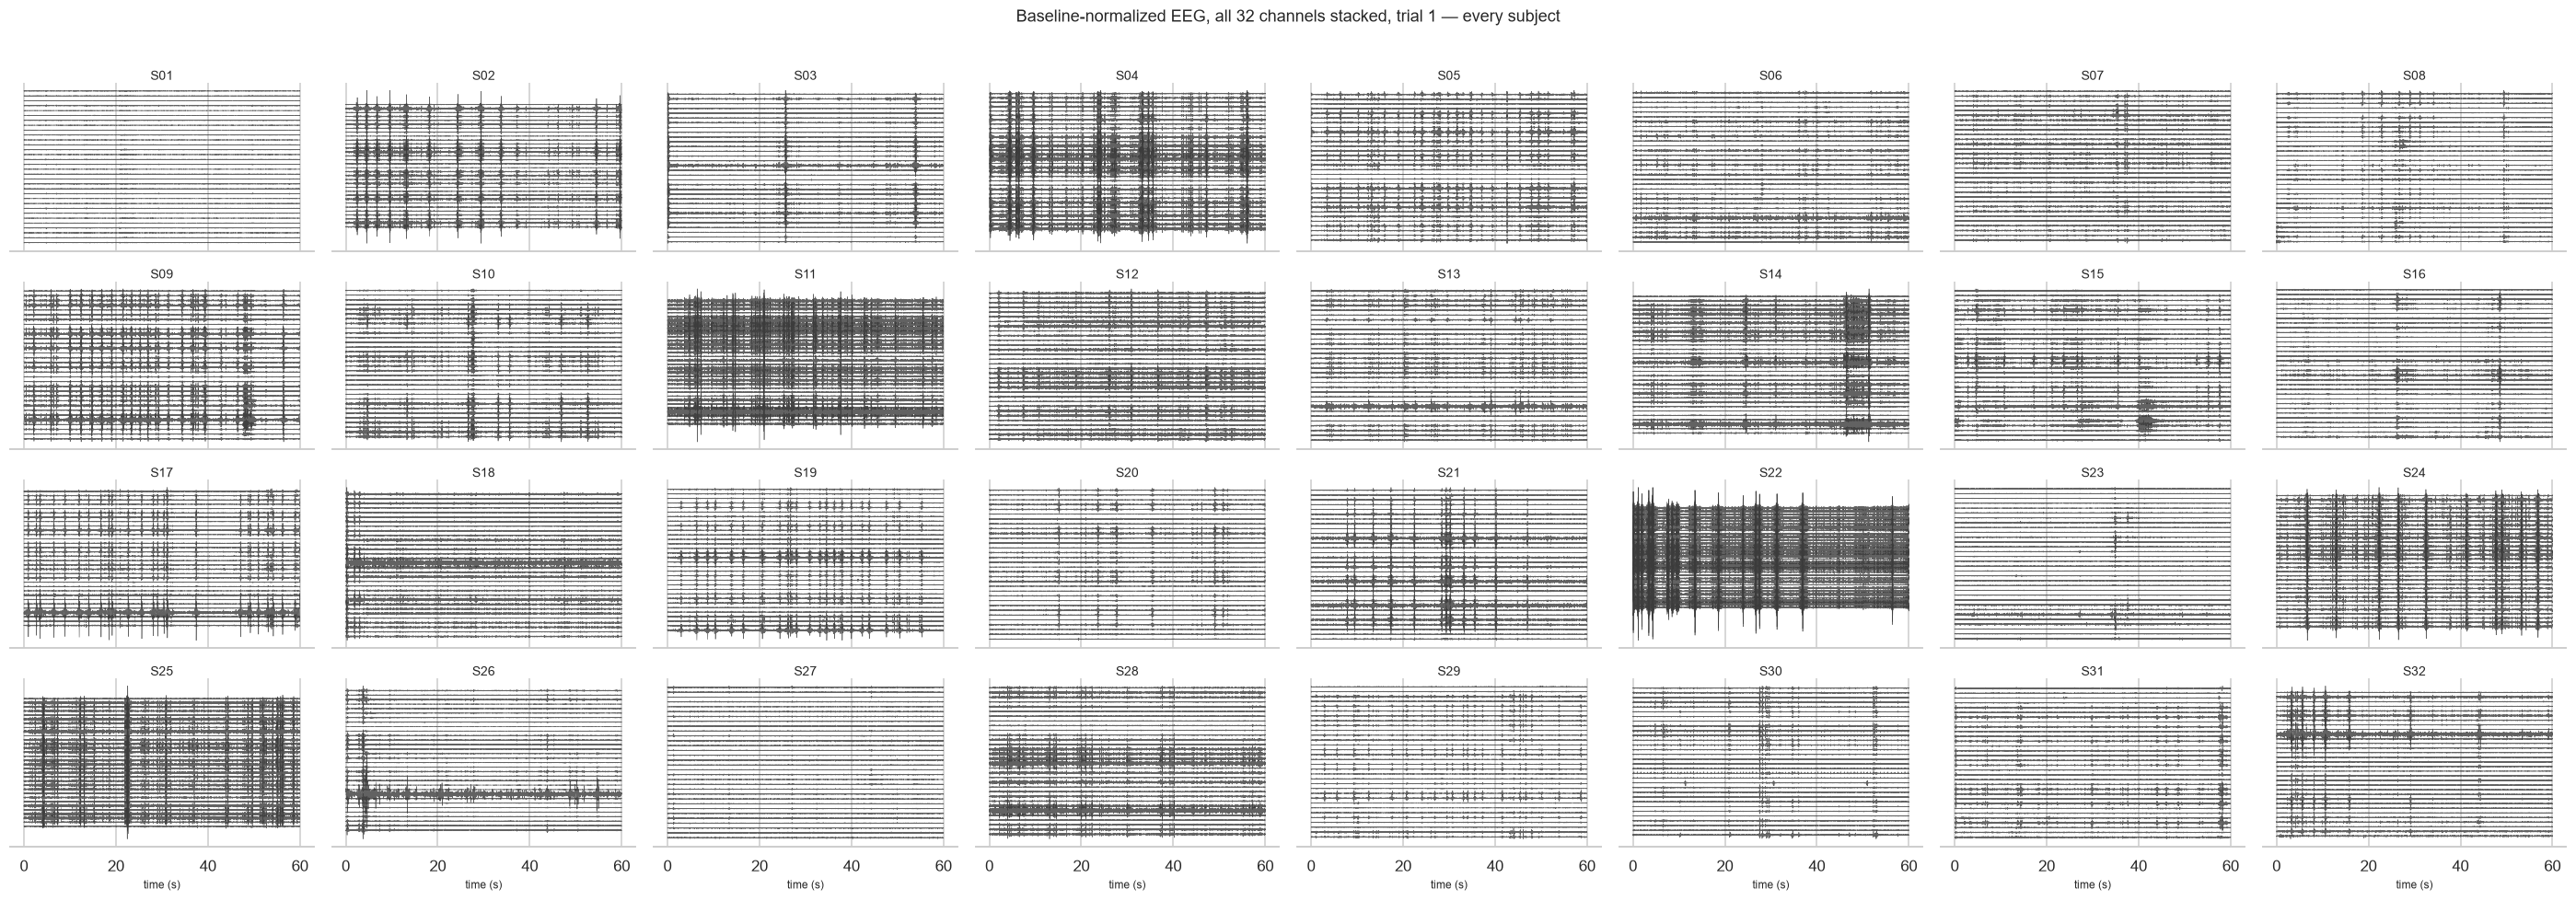

In [4]:
# ----- 2.1 Raw EEG overview: one panel per subject (QC) -----
N_COLS = 8
N_ROWS = int(np.ceil(len(SUBJECT_IDS) / N_COLS))
TRIAL_FOR_OVERVIEW = 0
OFFSET = 150  # fixed vertical offset between stacked channel traces, tuned for DEAP's amplitude scale

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(3.2 * N_COLS, 2.2 * N_ROWS), sharex=True)
axes = np.atleast_1d(axes).ravel()
time_axis = np.arange(TRIAL_SAMPLES) / FS

for ax, sid in zip(axes, SUBJECT_IDS):
    data, _ = load_subject(sid)
    trial_norm = baseline_normalize(data[TRIAL_FOR_OVERVIEW])  # (32, 7680)
    for ch_i in range(N_EEG_CHANNELS):
        ax.plot(time_axis, trial_norm[ch_i] + ch_i * OFFSET,
                color="#3b3b3b", linewidth=0.4, alpha=0.8)
    ax.set_title(f"S{sid:02d}", fontsize=9, pad=2)
    ax.set_yticks([])
    sns.despine(ax=ax, left=True)

for ax in axes[len(SUBJECT_IDS):]:
    ax.axis("off")

for ax in axes[-N_COLS:]:
    ax.set_xlabel("time (s)", fontsize=8)

fig.suptitle(f"Baseline-normalized EEG, all {N_EEG_CHANNELS} channels stacked, "
             f"trial {TRIAL_FOR_OVERVIEW + 1} \u2014 every subject", y=1.01, fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eeg_overview_all_subjects.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Build the full windowed dataset

Loops over every subject and trial, producing:
- `X_de` — `(N_windows, 128)` differential-entropy features
- `X_raw` — `(N_windows, 32, WINDOW_SAMPLES)` baseline-normalized raw windows
- `y_by_task` — a dict of binary label arrays, one per DEAP dimension (`valence`, `arousal`,
  `dominance`, `liking`), each `(N_windows,)`
- `groups` — subject id per window (for subject-independent splitting)

Results are cached to disk (`processed_cache/`) so re-running the notebook is instant. The cache
file name is schema-versioned (`CACHE_SCHEMA_VERSION`) so older caches built before dominance/
liking were tracked won't be silently reused.


In [5]:

from tqdm.auto import tqdm

CACHE_SCHEMA_VERSION = 2   # bump if the cached array set changes (e.g. new label dimensions)

def build_dataset(subject_ids):
    cache_path = CACHE_DIR / f"deap_windows_{WINDOW_SEC}s_{len(subject_ids)}subj_v{CACHE_SCHEMA_VERSION}.npz"
    if cache_path.exists() and not FORCE_REBUILD_CACHE:
        print(f"Loading cached dataset: {cache_path}")
        npz = np.load(cache_path)
        y_by_task = {task: npz[f"y_{task}"] for task in TASK_ORDER}
        return npz["X_de"], npz["X_raw"], y_by_task, npz["groups"]

    X_de_list, X_raw_list, groups_list = [], [], []
    y_lists = {task: [] for task in TASK_ORDER}
    for sid in tqdm(subject_ids, desc="Subjects"):
        data, labels = load_subject(sid)
        task_labels = {task: (labels[:, col] > LABEL_THRESHOLD).astype(np.int64)
                       for task, col in LABEL_COLUMNS.items()}
        for trial_idx in range(data.shape[0]):
            trial_norm = baseline_normalize(data[trial_idx])
            de_feats = compute_de_features(trial_norm)
            raw_wins = make_raw_windows(trial_norm)
            n_win = de_feats.shape[0]
            X_de_list.append(de_feats)
            X_raw_list.append(raw_wins)
            for task in TASK_ORDER:
                y_lists[task].append(np.full(n_win, task_labels[task][trial_idx], dtype=np.int64))
            groups_list.append(np.full(n_win, sid, dtype=np.int64))

    X_de = np.concatenate(X_de_list, axis=0)
    X_raw = np.concatenate(X_raw_list, axis=0)
    groups = np.concatenate(groups_list, axis=0)
    y_by_task = {task: np.concatenate(y_lists[task], axis=0) for task in TASK_ORDER}

    np.savez(cache_path, X_de=X_de, X_raw=X_raw, groups=groups,
              **{f"y_{task}": y for task, y in y_by_task.items()})
    print(f"Cached dataset to {cache_path}")
    return X_de, X_raw, y_by_task, groups


t0 = time.time()
X_de, X_raw, y_by_task, groups = build_dataset(SUBJECT_IDS)
print(f"Done in {time.time()-t0:.1f}s")
print("X_de:", X_de.shape, "| X_raw:", X_raw.shape, "| windows:", len(groups),
      "| subjects:", len(np.unique(groups)), "| tasks:", TASK_ORDER)


Loading cached dataset: D:\EEG\processed_cache\deap_windows_4s_32subj_v2.npz


Done in 1.1s
X_de: (19200, 128) | X_raw: (19200, 32, 512) | windows: 19200 | subjects: 32 | tasks: ['valence', 'arousal', 'dominance', 'liking']


## 4. Class balance

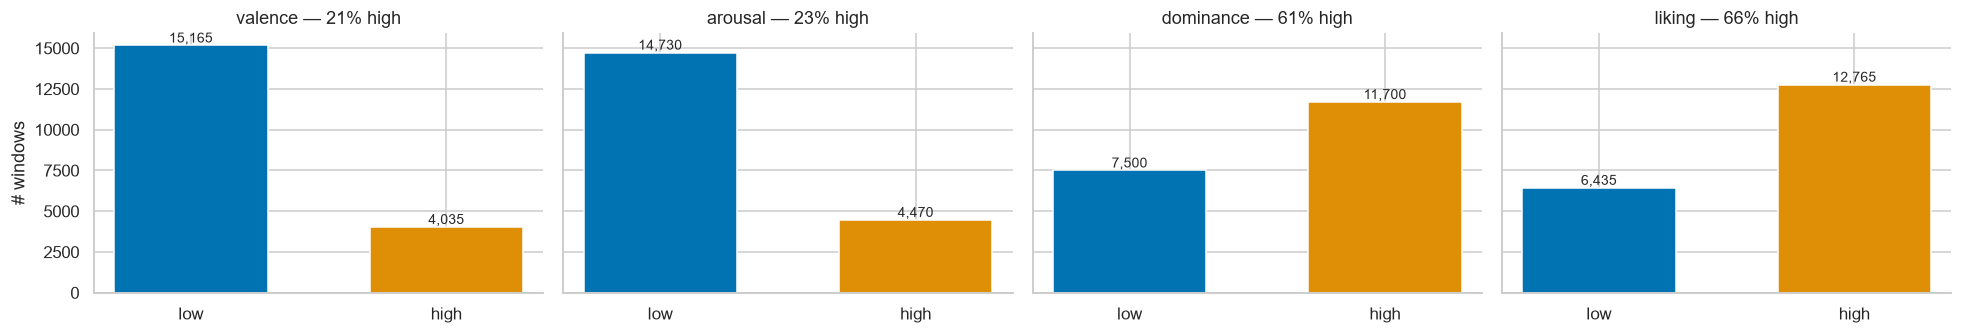

In [6]:

fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(4.5 * len(TASK_ORDER), 3.2), sharey=True)
for ax, task in zip(axes, TASK_ORDER):
    y = y_by_task[task]
    counts = pd.Series(y).map({0: "low", 1: "high"}).value_counts().reindex(["low", "high"])
    frac_high = counts["high"] / counts.sum()
    bars = ax.bar(counts.index, counts.values, color=[sns.color_palette("colorblind")[0],
                                                        sns.color_palette("colorblind")[1]], width=0.6)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():,}",
                ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{task} — {frac_high:.0%} high")
    ax.set_ylabel("# windows" if task == TASK_ORDER[0] else "")
    sns.despine(ax=ax)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "class_balance.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Track A — Differential Entropy features → classical ML

Six models, each wrapped in a `StandardScaler` pipeline (harmless for scale-invariant models
like Random Forest/XGBoost, necessary for kNN/SVM/MLP/LogReg), evaluated with 5-fold
**GroupKFold** (grouped by subject, so no subject's windows appear in both train and test —
this is the harder, more realistic subject-independent setting).

SVM-RBF training cost grows faster than linearly with sample count; to keep runtime reasonable
its training folds are capped at `SVM_MAX_TRAIN_SAMPLES` (a documented, pragmatic speed
trade-off — it does not affect the other five models).


In [7]:

SVM_MAX_TRAIN_SAMPLES = 8000

def get_ml_models():
    return {
        "LogisticRegression": LogisticRegression(max_iter=2000, random_state=SEED),
        "kNN": KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
        "RandomForest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
        "SVM-RBF": SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=SEED),
        "XGBoost": XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                  tree_method="hist", device=XGB_DEVICE,
                                  eval_metric="logloss", random_state=SEED),
        "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                              early_stopping=True, random_state=SEED),
    }


def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }


def run_ml_cv(X, y, groups, task_name, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    rows = []
    for model_name in MODEL_ORDER[:6]:
        fold_metrics = []
        fold_times = []
        for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
            model = get_ml_models()[model_name]
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            if model_name == "SVM-RBF" and len(X_train) > SVM_MAX_TRAIN_SAMPLES:
                rng = np.random.RandomState(SEED + fold_i)
                sub = rng.choice(len(X_train), SVM_MAX_TRAIN_SAMPLES, replace=False)
                X_train, y_train = X_train[sub], y_train[sub]

            pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
            t0 = time.time()
            pipe.fit(X_train, y_train)
            fold_times.append(time.time() - t0)

            y_pred = pipe.predict(X_test)
            y_prob = pipe.predict_proba(X_test)[:, 1]
            fold_metrics.append(compute_metrics(y_test, y_pred, y_prob))

        m = pd.DataFrame(fold_metrics)
        rows.append({
            "task": task_name, "model": model_name,
            "accuracy_mean": m.accuracy.mean(), "accuracy_std": m.accuracy.std(),
            "f1_mean": m.f1_macro.mean(), "f1_std": m.f1_macro.std(),
            "roc_auc_mean": m.roc_auc.mean(), "roc_auc_std": m.roc_auc.std(),
            "train_time_s": np.mean(fold_times),
        })
        print(f"[{task_name}] {model_name:<18} acc={m.accuracy.mean():.3f}+/-{m.accuracy.std():.3f} "
              f"f1={m.f1_macro.mean():.3f} auc={m.roc_auc.mean():.3f} "
              f"({np.mean(fold_times):.1f}s/fold)")
    return pd.DataFrame(rows)


results_ml = pd.concat(
    [run_ml_cv(X_de, y_by_task[task], groups, task) for task in TASK_ORDER],
    ignore_index=True,
)


[valence] LogisticRegression acc=0.672+/-0.141 f1=0.445 auc=0.449 (0.2s/fold)


[valence] kNN                acc=0.731+/-0.078 f1=0.464 auc=0.465 (0.0s/fold)


[valence] RandomForest       acc=0.779+/-0.069 f1=0.446 auc=0.501 (4.8s/fold)


[valence] SVM-RBF            acc=0.676+/-0.075 f1=0.469 auc=0.500 (14.1s/fold)


[valence] XGBoost            acc=0.754+/-0.087 f1=0.452 auc=0.455 (1.0s/fold)


...

[liking] kNN                acc=0.631+/-0.028 f1=0.481 auc=0.531 (0.0s/fold)


[liking] RandomForest       acc=0.643+/-0.018 f1=0.447 auc=0.528 (5.1s/fold)


[liking] SVM-RBF            acc=0.587+/-0.043 f1=0.517 auc=0.534 (18.0s/fold)


[liking] XGBoost            acc=0.635+/-0.025 f1=0.454 auc=0.505 (1.1s/fold)


[liking] MLP                acc=0.568+/-0.065 f1=0.474 auc=0.488 (2.5s/fold)


### Track A results

In [8]:
results_ml_sorted = results_ml.sort_values(["task", "accuracy_mean"], ascending=[True, False])
results_ml_sorted.to_csv(TABLES_DIR / "track_a_ml_results.csv", index=False)

display(results_ml_sorted
        .style.format({"accuracy_mean": "{:.3f}", "accuracy_std": "{:.3f}", "f1_mean": "{:.3f}",
                        "f1_std": "{:.3f}", "roc_auc_mean": "{:.3f}", "roc_auc_std": "{:.3f}",
                        "train_time_s": "{:.1f}"}))


,task,model,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,train_time_s
8,arousal,RandomForest,0.767,0.031,0.434,0.010,0.489,0.046,4.4
10,arousal,XGBoost,0.755,0.029,0.451,0.022,0.483,0.082,1.0
7,arousal,kNN,0.744,0.048,0.451,0.013,0.495,0.048,0.0
11,arousal,MLP,0.700,0.030,0.457,0.026,0.439,0.069,5.6
9,arousal,SVM-RBF,0.691,0.063,0.449,0.023,0.450,0.110,13.8
6,arousal,LogisticRegression,0.666,0.059,0.480,0.030,0.461,0.061,0.2
14,dominance,RandomForest,0.577,0.053,0.441,0.054,0.497,0.023,4.7
17,dominance,MLP,0.558,0.044,0.487,0.047,0.493,0.047,4.4
15,dominance,SVM-RBF,0.557,0.031,0.498,0.048,0.513,0.068,18.5
16,dominance,XGBoost,0.553,0.056,0.466,0.026,0.473,0.033,1.0


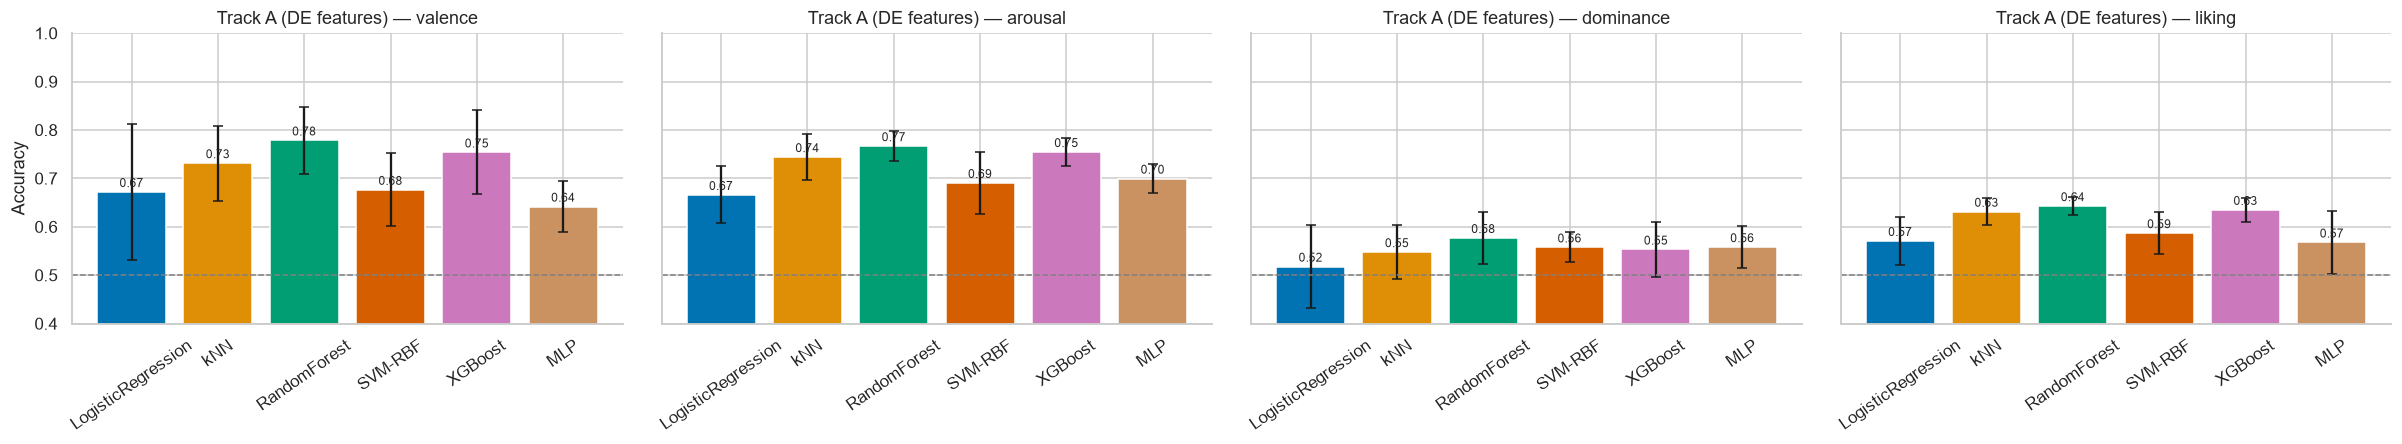

In [9]:

fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(5.5 * len(TASK_ORDER), 4.2), sharey=True)
for ax, task in zip(axes, TASK_ORDER):
    sub = results_ml[results_ml.task == task].set_index("model").reindex(MODEL_ORDER[:6])
    colors = [PALETTE[m] for m in sub.index]
    bars = ax.bar(sub.index, sub.accuracy_mean, yerr=sub.accuracy_std, capsize=3, color=colors)
    ax.set_title(f"Track A (DE features) — {task}")
    ax.set_ylabel("Accuracy" if task == TASK_ORDER[0] else "")
    ax.set_ylim(0.4, 1.0)
    ax.axhline(0.5, color="gray", lw=1, ls="--")
    ax.tick_params(axis="x", rotation=35)
    for b, v in zip(bars, sub.accuracy_mean):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
    sns.despine(ax=ax)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_a_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Track B — Raw baseline-normalized windows → deep learning

**Subject-independent split**: subjects (not windows) are split into train/val/test so a
subject's data never leaks across splits. With 32 subjects (or 8 in `QUICK_RUN`), this defaults
to roughly 70% / 15% / 15%.


In [10]:

def subject_independent_split(groups, test_size=0.15, val_size=0.15, seed=SEED):
    unique_subjects = np.unique(groups)
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    trainval_idx, test_idx = next(gss1.split(np.zeros(len(groups)), groups=groups))

    trainval_groups = groups[trainval_idx]
    relative_val_size = val_size / (1 - test_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=relative_val_size, random_state=seed)
    train_rel, val_rel = next(gss2.split(np.zeros(len(trainval_idx)), groups=trainval_groups))
    train_idx, val_idx = trainval_idx[train_rel], trainval_idx[val_rel]

    print(f"subjects -> train:{len(np.unique(groups[train_idx]))} "
          f"val:{len(np.unique(groups[val_idx]))} test:{len(np.unique(groups[test_idx]))} "
          f"| windows -> train:{len(train_idx)} val:{len(val_idx)} test:{len(test_idx)}")
    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = subject_independent_split(groups)


class EEGWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float().unsqueeze(1)   # (N,1,32,T)
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


subjects -> train:22 val:5 test:5 | windows -> train:13200 val:3000 test:3000


### 6.1 Model architectures

- **EEGNet** (Lawhern et al., 2018) — compact temporal conv → depthwise spatial conv →
  separable conv, designed specifically for EEG.
- **ShallowConvNet** (Schirrmeister et al., 2017) — temporal conv → spatial conv →
  square/log-power nonlinearity, inspired by band-power (FBCSP-style) features.
- **CNN-LSTM** — a spatial-temporal CNN front-end collapses the channel dimension, and a
  bidirectional LSTM models the resulting temporal sequence.
- **TSception** (Ding et al., 2022) — multi-scale temporal "inception" branches (different
  kernel sizes capture different temporal resolutions), fused with a *global* spatial conv and
  a hemisphere-asymmetry spatial conv (difference between symmetric left/right electrode pairs,
  using DEAP's standard 10-20 channel order). This is a simplified, faithful-in-spirit
  reimplementation, not a line-for-line reproduction of the original codebase.


In [11]:

class EEGNet(nn.Module):
    def __init__(self, n_channels=32, n_samples=WINDOW_SAMPLES, n_classes=2,
                 F1=8, D=2, F2=16, kernel_length=64, dropout=0.5):
        super().__init__()
        self.firstconv = nn.Sequential(
            nn.Conv2d(1, F1, (1, kernel_length), padding=(0, kernel_length // 2), bias=False),
            nn.BatchNorm2d(F1),
        )
        self.depthwiseConv = nn.Sequential(
            nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )
        self.separableConv = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_samples)
            flat_dim = self.separableConv(self.depthwiseConv(self.firstconv(dummy))).numel()
        self.classifier = nn.Linear(flat_dim, n_classes)

    def forward(self, x):
        x = self.firstconv(x)
        x = self.depthwiseConv(x)
        x = self.separableConv(x)
        return self.classifier(x.flatten(1))


class ShallowConvNet(nn.Module):
    def __init__(self, n_channels=32, n_samples=WINDOW_SAMPLES, n_classes=2,
                 n_filters=40, dropout=0.5):
        super().__init__()
        self.temporal_conv = nn.Conv2d(1, n_filters, (1, 25))
        self.spatial_conv = nn.Conv2d(n_filters, n_filters, (n_channels, 1), bias=False)
        self.bn = nn.BatchNorm2d(n_filters)
        self.pool = nn.AvgPool2d((1, 75), stride=(1, 15))
        self.dropout = nn.Dropout(dropout)
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_samples)
            flat_dim = self._features(dummy).numel()
        self.classifier = nn.Linear(flat_dim, n_classes)

    def _features(self, x):
        x = self.temporal_conv(x)
        x = self.spatial_conv(x)
        x = self.bn(x)
        x = torch.square(x)
        x = self.pool(x)
        x = torch.log(torch.clamp(x, min=1e-6))
        return x

    def forward(self, x):
        x = self._features(x)
        x = self.dropout(x)
        return self.classifier(x.flatten(1))


class CNNLSTM(nn.Module):
    def __init__(self, n_channels=32, n_samples=WINDOW_SAMPLES, n_classes=2,
                 cnn_channels=32, lstm_hidden=64, dropout=0.5):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, cnn_channels, (n_channels, 5), padding=(0, 2)),
            nn.BatchNorm2d(cnn_channels), nn.ELU(), nn.MaxPool2d((1, 2)),
            nn.Conv2d(cnn_channels, cnn_channels * 2, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(cnn_channels * 2), nn.ELU(), nn.MaxPool2d((1, 2)),
        )
        self.lstm = nn.LSTM(input_size=cnn_channels * 2, hidden_size=lstm_hidden,
                             num_layers=1, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden * 2, n_classes)

    def forward(self, x):
        x = self.conv(x)            # (B, C, 1, T')
        x = x.squeeze(2).permute(0, 2, 1)   # (B, T', C)
        _, (h, _) = self.lstm(x)
        feat = torch.cat([h[-2], h[-1]], dim=1)
        return self.classifier(self.dropout(feat))


class TSception(nn.Module):
    def __init__(self, n_channels=32, n_samples=WINDOW_SAMPLES, n_classes=2, fs=FS,
                 num_t_filters=9, num_s_filters=6, t_fixed_len=32, dropout=0.5,
                 left_idx=None, right_idx=None):
        super().__init__()
        self.left_idx = left_idx if left_idx is not None else LEFT_IDX
        self.right_idx = right_idx if right_idx is not None else RIGHT_IDX
        kernel_sizes = [max(2, int(f * fs)) for f in (0.5, 0.25, 0.125)]
        self.t_branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(1, num_t_filters, (1, k), stride=(1, max(1, k // 2))),
                nn.BatchNorm2d(num_t_filters), nn.ELU(),
                nn.AdaptiveAvgPool2d((n_channels, t_fixed_len)),
            ) for k in kernel_sizes
        ])
        n_pairs = len(self.left_idx)
        self.s_global = nn.Sequential(
            nn.Conv2d(num_t_filters * 3, num_s_filters, (n_channels, 1)),
            nn.BatchNorm2d(num_s_filters), nn.ELU())
        self.s_pair = nn.Sequential(
            nn.Conv2d(num_t_filters * 3, num_s_filters, (n_pairs, 1)),
            nn.BatchNorm2d(num_s_filters), nn.ELU())
        self.fusion = nn.Sequential(
            nn.Conv2d(num_s_filters, num_s_filters, (2, 1)),
            nn.BatchNorm2d(num_s_filters), nn.ELU(),
            nn.AdaptiveAvgPool2d((1, 8)))
        self.dropout = nn.Dropout(dropout)
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_samples)
            flat_dim = self._forward_features(dummy).numel()
        self.classifier = nn.Linear(flat_dim, n_classes)

    def _forward_features(self, x):
        t_outs = [b(x) for b in self.t_branches]
        t_cat = torch.cat(t_outs, dim=1)                       # (B, F*3, 32, t_fixed_len)
        s_g = self.s_global(t_cat)                             # (B, S, 1, T)
        left = t_cat[:, :, self.left_idx, :]
        right = t_cat[:, :, self.right_idx, :]
        s_asym = torch.abs(self.s_pair(left) - self.s_pair(right))   # (B, S, 1, T)
        s_cat = torch.cat([s_g, s_asym], dim=2)                # (B, S, 2, T)
        return self.fusion(s_cat)

    def forward(self, x):
        feat = self.dropout(self._forward_features(x))
        return self.classifier(feat.flatten(1))


DL_MODEL_BUILDERS = {
    "ShallowConvNet": ShallowConvNet,
    "EEGNet": EEGNet,
    "CNN-LSTM": CNNLSTM,
    "TSception": TSception,
}

# quick shape sanity check
for name, builder in DL_MODEL_BUILDERS.items():
    m = builder()
    out = m(torch.zeros(2, 1, N_EEG_CHANNELS, WINDOW_SAMPLES))
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:<15} output={tuple(out.shape)}  params={n_params:,}")
    del m


ShallowConvNet  output=(2, 2)  params=54,562
EEGNet          output=(2, 2)  params=2,130
CNN-LSTM        output=(2, 2)  params=82,466
TSception       output=(2, 2)  params=8,765


### 6.2 Training loop

In [12]:

def train_torch_model(model_builder, train_ds, val_ds, test_ds, epochs=N_EPOCHS,
                       batch_size=BATCH_SIZE, lr=1e-3, weight_decay=1e-4, patience=PATIENCE):
    model = model_builder().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=(DEVICE.type == "cuda"))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size * 2, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size * 2, shuffle=False, pin_memory=True)

    best_val_loss, best_state, no_improve = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
                out = model(xb)
                loss = criterion(out, yb)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_ds)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
                    out = model(xb)
                    loss = criterion(out, yb)
                val_loss += loss.item() * xb.size(0)
                correct += (out.argmax(1) == yb).sum().item()
        val_loss /= len(val_ds)
        val_acc = correct / len(val_ds)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"  epoch {epoch+1:>3}/{epochs}  train_loss={train_loss:.4f}  "
              f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("  early stopping")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    preds, probs, trues = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            out = model(xb.to(DEVICE))
            probs.append(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
            preds.append(out.argmax(1).cpu().numpy())
            trues.append(yb.numpy())
    y_pred, y_prob, y_true = np.concatenate(preds), np.concatenate(probs), np.concatenate(trues)
    metrics = compute_metrics(y_true, y_pred, y_prob)
    return model, history, metrics, (y_true, y_pred, y_prob)


### 6.3 Train all four deep models on all four tasks

4 architectures × 4 label dimensions = **16 training runs** (up to `N_EPOCHS` each, with early
stopping). This is the expensive part of the notebook — expect it to take roughly 2x as long as
a valence/arousal-only run.


In [13]:

dl_results_rows = []
dl_histories = {}
dl_preds = {}

for task_name in TASK_ORDER:
    y_all = y_by_task[task_name]
    train_ds = EEGWindowDataset(X_raw[train_idx], y_all[train_idx])
    val_ds = EEGWindowDataset(X_raw[val_idx], y_all[val_idx])
    test_ds = EEGWindowDataset(X_raw[test_idx], y_all[test_idx])

    for model_name, builder in DL_MODEL_BUILDERS.items():
        print(f"\n=== {task_name} / {model_name} ===")
        t0 = time.time()
        model, history, metrics, preds = train_torch_model(builder, train_ds, val_ds, test_ds)
        train_time = time.time() - t0
        n_params = sum(p.numel() for p in model.parameters())

        dl_results_rows.append({
            "task": task_name, "model": model_name,
            "accuracy_mean": metrics["accuracy"], "accuracy_std": 0.0,
            "f1_mean": metrics["f1_macro"], "f1_std": 0.0,
            "roc_auc_mean": metrics["roc_auc"], "roc_auc_std": 0.0,
            "train_time_s": train_time, "n_params": n_params,
        })
        dl_histories[(task_name, model_name)] = history
        dl_preds[(task_name, model_name)] = preds
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

results_dl = pd.DataFrame(dl_results_rows)



=== valence / ShallowConvNet ===


  epoch   1/40  train_loss=0.5332  val_loss=0.6659  val_acc=0.7327


  epoch   2/40  train_loss=0.4850  val_loss=0.6000  val_acc=0.7350


  epoch   3/40  train_loss=0.4714  val_loss=0.6075  val_acc=0.7303


  epoch   4/40  train_loss=0.4561  val_loss=0.6417  val_acc=0.7180


...

  epoch   9/40  train_loss=0.5563  val_loss=0.5908  val_acc=0.7207


  epoch  10/40  train_loss=0.5388  val_loss=0.5952  val_acc=0.7137


  epoch  11/40  train_loss=0.5298  val_loss=0.5918  val_acc=0.7133


  epoch  12/40  train_loss=0.5208  val_loss=0.6067  val_acc=0.7077


  epoch  13/40  train_loss=0.5139  val_loss=0.6101  val_acc=0.7133
  early stopping


### Track B results

In [14]:
results_dl_sorted = results_dl.sort_values(["task", "accuracy_mean"], ascending=[True, False])
results_dl_sorted.to_csv(TABLES_DIR / "track_b_dl_results.csv", index=False)

display(results_dl_sorted
        .style.format({"accuracy_mean": "{:.3f}", "f1_mean": "{:.3f}", "roc_auc_mean": "{:.3f}",
                        "train_time_s": "{:.1f}", "n_params": "{:,}"}))


,task,model,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,train_time_s,n_params
6,arousal,CNN-LSTM,0.774,0.000000,0.441,0.000000,0.605,0.000000,9.9,"82,466"
7,arousal,TSception,0.768,0.000000,0.446,0.000000,0.483,0.000000,14.2,"8,765"
4,arousal,ShallowConvNet,0.761,0.000000,0.458,0.000000,0.557,0.000000,31.3,"54,562"
5,arousal,EEGNet,0.699,0.000000,0.572,0.000000,0.607,0.000000,28.7,"2,130"
11,dominance,TSception,0.589,0.000000,0.414,0.000000,0.475,0.000000,10.6,"8,765"
10,dominance,CNN-LSTM,0.505,0.000000,0.359,0.000000,0.452,0.000000,8.2,"82,466"
8,dominance,ShallowConvNet,0.465,0.000000,0.342,0.000000,0.408,0.000000,23.5,"54,562"
9,dominance,EEGNet,0.453,0.000000,0.342,0.000000,0.288,0.000000,23.0,"2,130"
13,liking,EEGNet,0.600,0.000000,0.375,0.000000,0.423,0.000000,17.3,"2,130"
14,liking,CNN-LSTM,0.599,0.000000,0.384,0.000000,0.497,0.000000,11.3,"82,466"


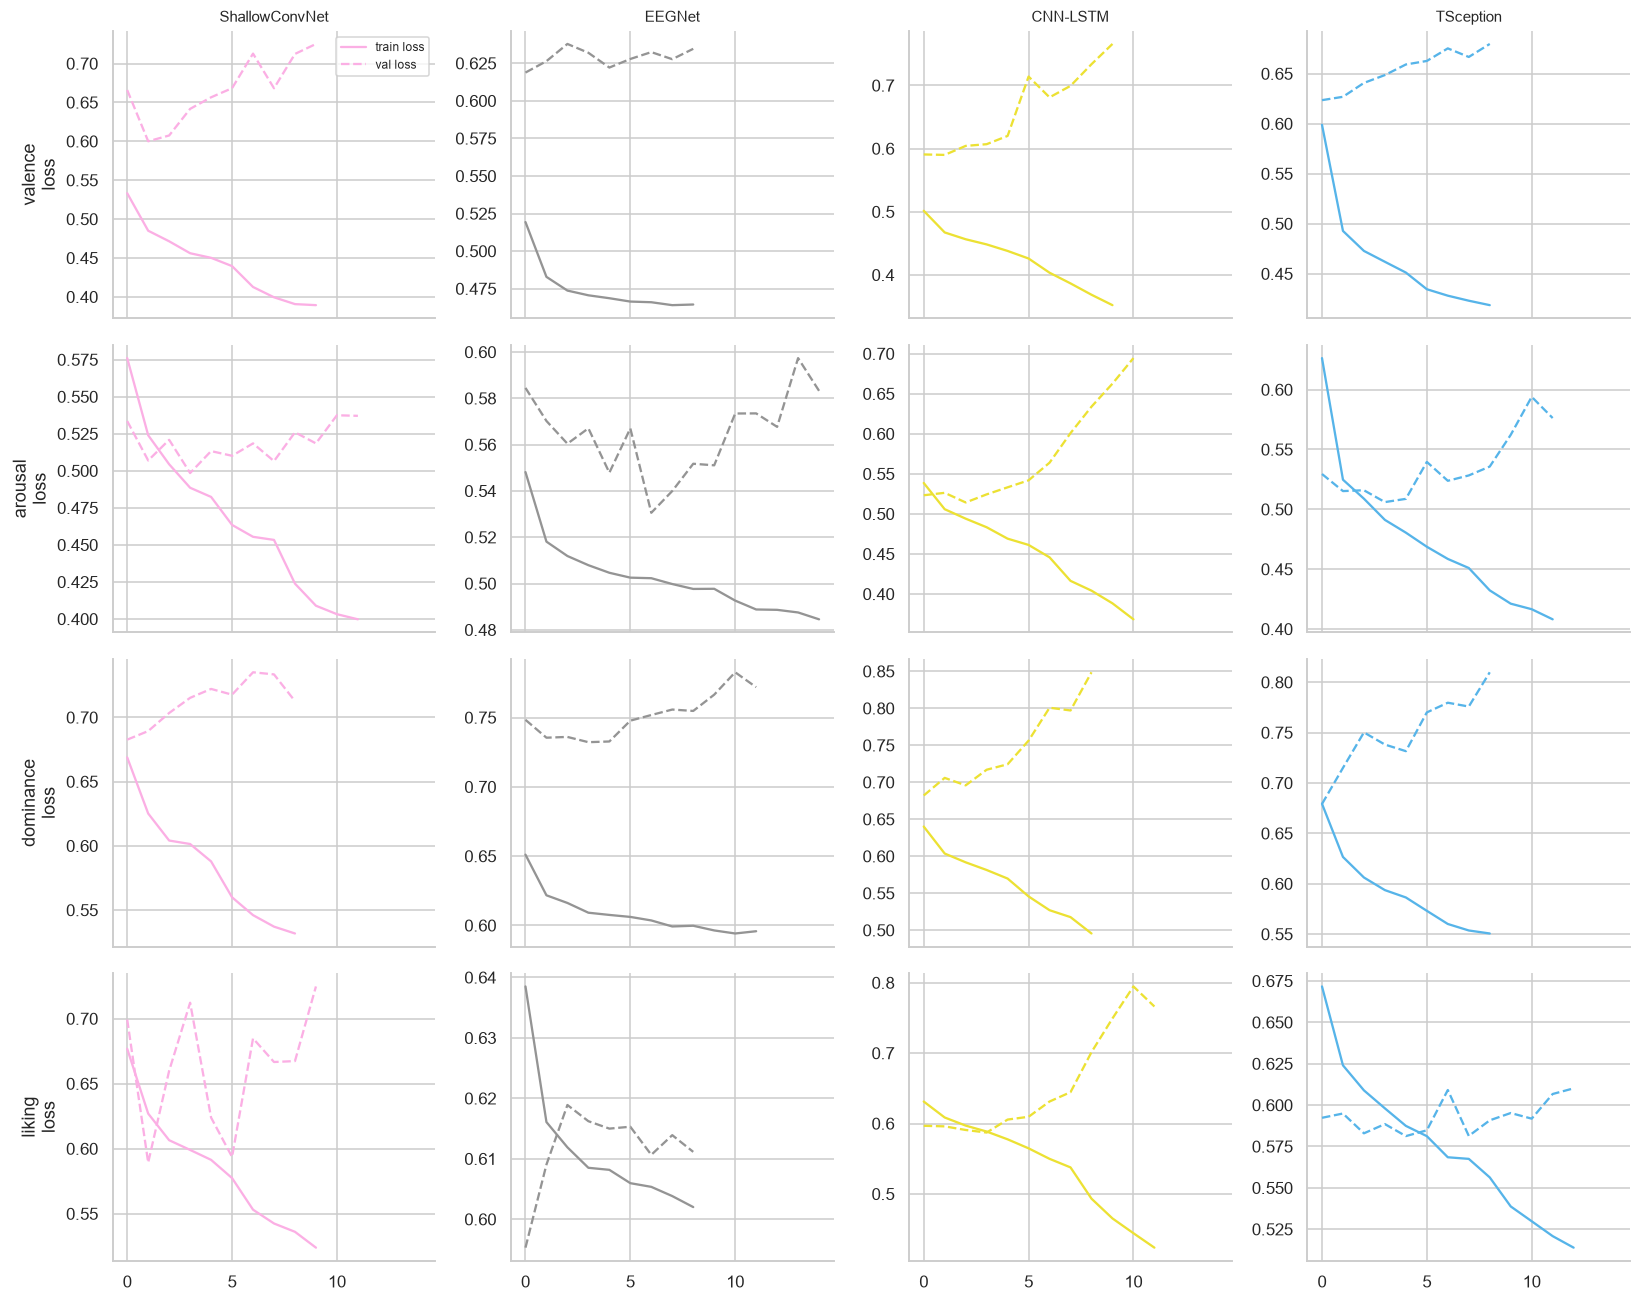

In [15]:

fig, axes = plt.subplots(len(TASK_ORDER), len(DL_MODEL_BUILDERS),
                          figsize=(15, 3 * len(TASK_ORDER)), sharex=True)
for col, model_name in enumerate(DL_MODEL_BUILDERS):
    for row, task_name in enumerate(TASK_ORDER):
        ax = axes[row, col]
        h = dl_histories[(task_name, model_name)]
        ax.plot(h["train_loss"], label="train loss", color=PALETTE[model_name])
        ax.plot(h["val_loss"], label="val loss", color=PALETTE[model_name], ls="--")
        if row == 0:
            ax.set_title(model_name, fontsize=10)
        if col == 0:
            ax.set_ylabel(f"{task_name}\nloss")
        sns.despine(ax=ax)
axes[0, 0].legend(fontsize=8, loc="upper right")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_b_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Combined comparative analysis — all 10 models

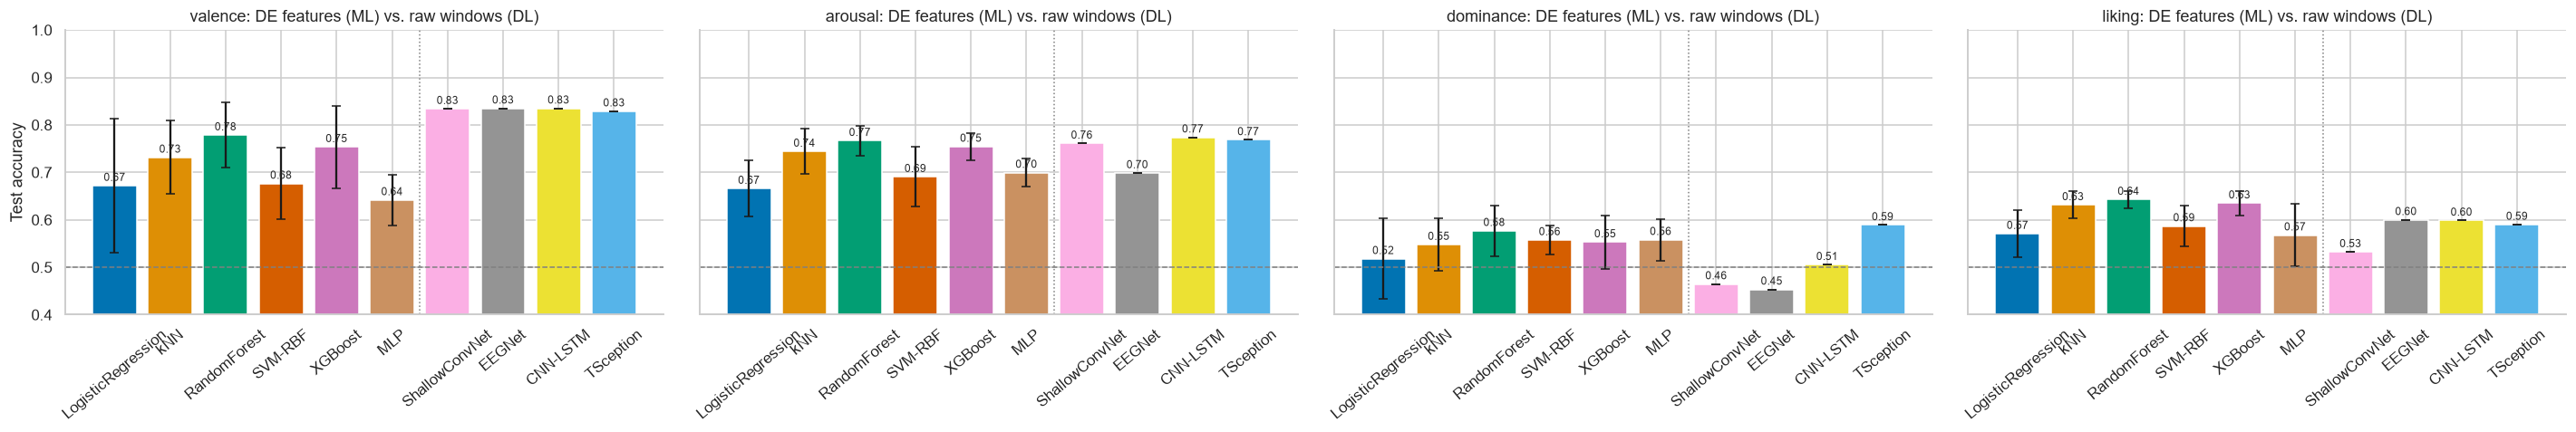

,task,model,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,train_time_s,n_params
0,arousal,CNN-LSTM,0.774,0.000,0.441,0.000000,0.605,0.000000,9.9,82466.000000
1,arousal,TSception,0.768,0.000,0.446,0.000000,0.483,0.000000,14.2,8765.000000
2,arousal,RandomForest,0.767,0.031,0.434,0.010314,0.489,0.046144,4.4,—
3,arousal,ShallowConvNet,0.761,0.000,0.458,0.000000,0.557,0.000000,31.3,54562.000000
4,arousal,XGBoost,0.755,0.029,0.451,0.022227,0.483,0.082474,1.0,—
5,arousal,kNN,0.744,0.048,0.451,0.013157,0.495,0.047582,0.0,—
6,arousal,MLP,0.700,0.030,0.457,0.025997,0.439,0.069249,5.6,—
7,arousal,EEGNet,0.699,0.000,0.572,0.000000,0.607,0.000000,28.7,2130.000000
8,arousal,SVM-RBF,0.691,0.063,0.449,0.022953,0.450,0.110463,13.8,—
9,arousal,LogisticRegression,0.666,0.059,0.480,0.029993,0.461,0.060856,0.2,—


In [16]:

results_all = pd.concat([results_ml, results_dl], ignore_index=True, sort=False)

fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(6.5 * len(TASK_ORDER), 4.5), sharey=True)
for ax, task in zip(axes, TASK_ORDER):
    sub = results_all[results_all.task == task].set_index("model").reindex(MODEL_ORDER)
    colors = [PALETTE[m] for m in sub.index]
    bars = ax.bar(sub.index, sub.accuracy_mean, yerr=sub.accuracy_std.fillna(0), capsize=3, color=colors)
    ax.axvline(5.5, color="gray", lw=1, ls=":")
    ax.axhline(0.5, color="gray", lw=1, ls="--")
    ax.set_title(f"{task}: DE features (ML) vs. raw windows (DL)")
    ax.set_ylabel("Test accuracy" if task == TASK_ORDER[0] else "")
    ax.set_ylim(0.4, 1.0)
    ax.tick_params(axis="x", rotation=40)
    for b, v in zip(bars, sub.accuracy_mean):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
    sns.despine(ax=ax)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "combined_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

results_all_sorted = results_all.sort_values(["task", "accuracy_mean"], ascending=[True, False]).reset_index(drop=True)
results_all_sorted.to_csv(TABLES_DIR / "combined_results_all.csv", index=False)

display(results_all_sorted
        .style.format({"accuracy_mean": "{:.3f}", "accuracy_std": "{:.3f}", "f1_mean": "{:.3f}",
                        "roc_auc_mean": "{:.3f}", "train_time_s": "{:.1f}"}, na_rep="—"))


### Confusion matrices — best model per task

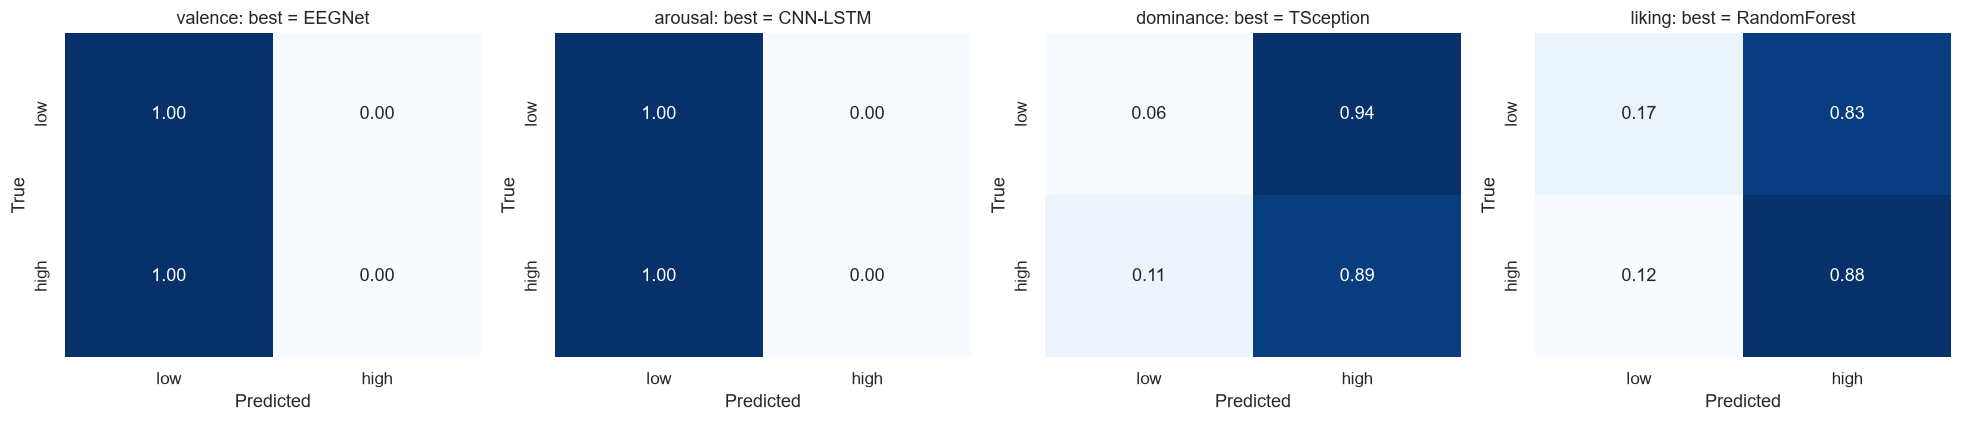

In [17]:

fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(4.5 * len(TASK_ORDER), 4))
for ax, task in zip(axes, TASK_ORDER):
    best_row = results_all[results_all.task == task].sort_values("accuracy_mean", ascending=False).iloc[0]
    best_model = best_row["model"]

    if best_model in DL_MODEL_BUILDERS:
        y_true, y_pred, _ = dl_preds[(task, best_model)]
    else:
        y = y_by_task[task]
        gkf = GroupKFold(n_splits=5)
        train_i, test_i = next(gkf.split(X_de, y, groups))
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", get_ml_models()[best_model])])
        pipe.fit(X_de[train_i], y[train_i])
        y_true, y_pred = y[test_i], pipe.predict(X_de[test_i])

    cm = confusion_matrix(y_true, y_pred, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["low", "high"], yticklabels=["low", "high"])
    ax.set_title(f"{task}: best = {best_model}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrices_best_models.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Discussion

*Originally written as a template ("interpret the tables once the run completes")
before Track A/B had actually been run. The notebook has since been run end-to-end,
so this section is rewritten below against the real numbers
(`track_a_ml_results.csv` / `track_b_dl_results.csv`) rather than left as a
hypothetical. Sections 9-18 then subject this initial picture to a much more
rigorous stress-test — see §13 and the cross-corpus result added to §12 for how it
holds up.*

- **DE features vs. raw windows**: mixed, not a clean win for either track. By best
  ROC-AUC per task, Track B (deep) edges out Track A (classical) on valence (EEGNet
  0.561 vs. RandomForest 0.501) and arousal (EEGNet 0.607 vs. kNN 0.495), while Track A
  edges out Track B on dominance (SVM-RBF 0.513 vs. TSception 0.475) and liking
  (SVM-RBF 0.534 vs. CNN-LSTM 0.497). No model in either track clears ~0.61 AUC on any
  task. That's the headline this early comparison actually contains: every one of the
  10 models, on every one of the 4 tasks, sits in the same narrow 0.45-0.61 band —
  barely-to-not-quite above chance. Sections 9-18 spend the rest of the notebook trying
  to explain that band away (richer features, more data, better labels, alignment,
  adversarial training...) and, section 12's cross-corpus result aside, never do.
- **Across the four dimensions**: the real class balance (computed from the cached
  windows, see §4) is valence 21.0% high / 79.0% low, arousal 23.3%/76.7%, dominance
  60.9%/39.1%, liking 66.5%/33.5% — **valence is the most skewed dimension, not
  liking** (correcting this section's original guess). That skew explains the single
  most misleading number in the Track A/B tables: Track B's valence models hit 83.5%
  accuracy (EEGNet, CNN-LSTM) while scoring only ~0.56 AUC, and Track A's valence
  RandomForest hits 77.9% accuracy at 0.50 AUC — both are within a couple points of
  the 79% majority-class baseline, the textbook signature of a classifier leaning on
  class imbalance rather than genuine signal (named explicitly, and partially fixed for
  valence specifically, by the AUC-margin loss in §17.3). Arousal shows the same
  pattern less severely. Dominance and liking, being closer to balanced, give a fairer
  read of accuracy — and notably dominance/EEGNet posts AUC **0.288**, below chance,
  the worst single result in either track and an early instance of the task-specific
  instability (arousal/dominance faring worse under representation-perturbing changes)
  that recurs throughout §16-17.
- **Compute cost vs. accuracy**: Track A's cheapest models (kNN, XGBoost, Logistic
  Regression: 0.02-1.1s per fold) are 10-1000x cheaper than any Track B model
  (9-32s per run), and SVM-RBF is Track A's one expensive outlier (~15-19s, sample-capped
  per §5's own note). But the AUC gap to Track B's best models is small (≤0.06-0.11 AUC
  where Track B wins at all) and Track A's numbers are 5-fold `GroupKFold` means (a real
  cross-validated estimate) versus Track B's single train/val/test split (`std=0` in the
  CSV is not "zero variance," it's "n=1" — §11 later runs Track B repeated to get an
  actual spread). Given that, and given neither track clears the 0.61 AUC ceiling, DE +
  classical is the more defensible choice here on cost *and* on estimate reliability, not
  just cost.
- **Subject independence is the hard setting**: within-subject (or even random,
  non-grouped) splits typically inflate accuracy substantially versus the
  subject-independent protocol used here, because consecutive windows from the same
  trial/subject are highly correlated. Section 13 makes this concrete: this notebook's
  genuine subject-independent AUC (~0.45-0.56 across the board) sits far below the
  source paper's own reported 0.97 ROC-AUC on the same dataset — strong circumstantial
  evidence that published DEAP numbers in this range come from a leakier split, not a
  better model.
- **Where this actually goes**: this section's own numbers are the first data point in a
  pattern that holds for the rest of the notebook, not an isolated result to move past.
  §13 confirms the near-chance ceiling survives richer features, nested tuning, more
  data, and better label definitions; §12's cross-corpus addition then shows the *same*
  pipeline reaches a real AUC of 0.673 on SEED-IV under an equivalent protocol — meaning
  the ceiling documented here is attributable to DEAP specifically, not to
  subject-independent EEG emotion decoding being hopeless in general.

### Extending this notebook
- Swap `GroupShuffleSplit` for full Leave-One-Subject-Out (32-fold) evaluation of the DL
  track for a more robust (but ~10-30x slower) estimate. *Still open* — §15 ran a true
  32-fold LOSO, but only for Track A/XGBoost (cheap enough); Track B still uses
  single/repeated splits (§6, §11), never full per-subject LOSO.
- Add data augmentation (channel dropout, time-warping, mixup) for the DL models.
  *Partially done* — §11 adds 50%-overlapping windows as a mild augmentation-adjacent
  device (explicitly flagged there as not equivalent to new information), but literal
  channel dropout / time-warping / mixup were never implemented.
- Try continuous regression (RMSE/CCC on 1-9 ratings) instead of binarized
  classification. *Still open* — every section in this notebook, including the label-
  cleanup ablation in §14, stays within binarized classification.
- Add SHAP/permutation importance on the DE features to see which channels/bands drive
  predictions, and compare against DL saliency maps (Grad-CAM on the spatial conv
  layers). *Half done* — §17.5 runs the SHAP diagnostic on Track A's DE features
  (finding diffuse, not concentrated, importance); a Track B Grad-CAM comparison was
  never implemented.

## 9. Richer Track A features — Hjorth, frontal/hemispheric alpha asymmetry, connectivity

Track A so far uses only band-power Differential Entropy (4 bands x 32 channels = 128
features). Three additional, cheap-to-compute feature families are added here, all
derived from the same baseline-normalized signal used for DE (*before* the
per-window z-scoring applied only for the DL track's raw-window input):

- **Hjorth parameters** (activity, mobility, complexity) — 3 x 32 = 96 features,
  classic time-domain complexity descriptors that DE/HFD-only pipelines miss.
- **Frontal/hemispheric alpha asymmetry (FAA)** — 14 features, one per left/right
  electrode pair, `alpha_power[right] - alpha_power[left]`. This is the classic
  valence marker from the Davidson asymmetry literature (the 4 canonical frontal
  pairs — Fp1/Fp2, F3/F4, F7/F8, FC5/FC6 — are a subset of the 14; the rest extend
  the same idea to the other hemispheric pairs already used by TSception's
  asymmetry branch).
- **Connectivity (PLV + coherence)** — 19 curated channel pairs (14 interhemispheric
  homologs + 5 canonical fronto-parietal/occipital pairs), PLV in alpha and beta
  bands (38 features) plus alpha-band coherence (19 features) = 57 features.

Implementation: `scripts/rich_features.py` (unit-tested against synthetic data —
shape and [0,1]-boundedness checks for PLV/coherence — and its DE computation was
verified to match the existing `X_de` cache exactly on real DEAP subjects before
trusting the rest). Full-feature build for all 32 subjects: `scripts/build_extended_features.py`
(~100s, cached to `processed_cache/deap_features_ext_v1.npz`, 19,200 windows x
{128 DE + 96 Hjorth + 14 FAA + 57 connectivity} = 295 features total).

In [18]:
import sys
sys.path.insert(0, str(Path(r"D:/EEG/scripts")))
import rich_features as rf

# sanity check on one real subject/trial, mirroring the DE/HFD check in section 2
_d, _l = load_subject(SUBJECT_IDS[0])
_norm = baseline_normalize(_d[0])
_hjorth = rf.compute_hjorth(_norm)
_faa = rf.compute_alpha_asymmetry(compute_de_features(_norm))
_conn = rf.compute_connectivity(_norm)
print("Hjorth features per trial:", _hjorth.shape, " (expect (15, 96))")
print("FAA features per trial:   ", _faa.shape, "  (expect (15, 14))")
print("Connectivity per trial:   ", _conn.shape, "  (expect (15, 57))")
del _d, _l, _norm, _hjorth, _faa, _conn


Hjorth features per trial: (15, 96)  (expect (15, 96))
FAA features per trial:    (15, 14)   (expect (15, 14))
Connectivity per trial:    (15, 57)   (expect (15, 57))


In [19]:
EXT_CACHE = CACHE_DIR / "deap_features_ext_v1.npz"
ext_npz = np.load(EXT_CACHE)
X_de_ext, X_hjorth, X_faa, X_conn = (ext_npz["X_de"], ext_npz["X_hjorth"],
                                      ext_npz["X_faa"], ext_npz["X_conn"])
print("X_de:", X_de_ext.shape, "| X_hjorth:", X_hjorth.shape,
      "| X_faa:", X_faa.shape, "| X_conn:", X_conn.shape)
# The extended cache always covers all 32 subjects; X_de only matches it row-for-row
# when this run also used all 32 (i.e. QUICK_RUN is off). Under QUICK_RUN, skip the
# exact-match assertion rather than fail on an expected shape mismatch.
if SUBJECT_IDS == ALL_SUBJECT_IDS:
    assert np.allclose(X_de_ext, X_de), "extended-feature cache's DE must match the section-3 X_de exactly"
    print("DE features cross-checked identical to the section-3 cache: OK")
else:
    print(f"QUICK_RUN is on ({len(SUBJECT_IDS)}/{len(ALL_SUBJECT_IDS)} subjects) -- "
          f"skipping the exact DE cross-check, which assumes the full 32-subject cache.")


X_de: (19200, 128) | X_hjorth: (19200, 96) | X_faa: (19200, 14) | X_conn: (19200, 57)
DE features cross-checked identical to the section-3 cache: OK


### Track A feature-set ablation

Ablation (`scripts/track_a_ablation.py`, single `GroupKFold(5)` pass, subject-grouped,
3 representative models x 6 feature-set combinations x 4 tasks = 360 fits, ~37 min)
compares DE-only against each addition and the full combined set.

,feature_set,n_features,task,model,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,train_time_s
41,DE+Connectivity,185,arousal,XGBoost,0.764,0.028782,0.438,0.006890,0.497,0.050337,5.670305
29,DE+FAA,142,arousal,XGBoost,0.753,0.029390,0.445,0.016135,0.491,0.046440,3.453186
4,DE_only,128,arousal,RandomForest,0.767,0.030915,0.434,0.010314,0.489,0.046144,5.899678
40,DE+Connectivity,185,arousal,RandomForest,0.767,0.031506,0.434,0.010528,0.488,0.050735,11.173490
65,Full (DE+Hjorth+FAA+Conn),295,arousal,XGBoost,0.764,0.030212,0.438,0.011568,0.482,0.045246,11.985779
28,DE+FAA,142,arousal,RandomForest,0.766,0.030681,0.437,0.012374,0.481,0.048293,8.332057
64,Full (DE+Hjorth+FAA+Conn),295,arousal,RandomForest,0.766,0.031216,0.434,0.010409,0.479,0.057698,16.149552
53,DE+Hjorth+FAA,238,arousal,XGBoost,0.757,0.021774,0.445,0.025850,0.472,0.023221,7.745054
17,DE+Hjorth,224,arousal,XGBoost,0.759,0.026242,0.438,0.014035,0.471,0.037730,5.673671
5,DE_only,128,arousal,XGBoost,0.758,0.022981,0.441,0.015130,0.468,0.062707,2.989292


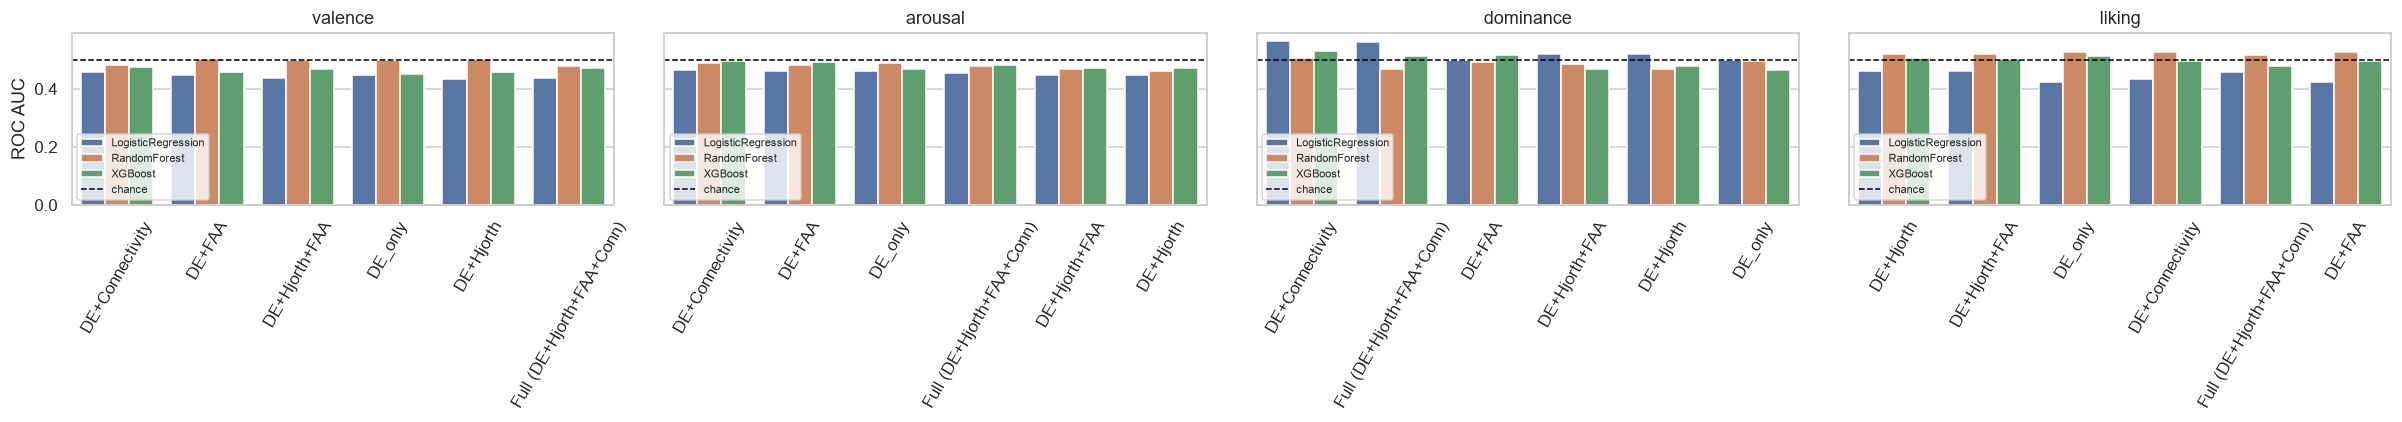

Best AUC anywhere in the ablation, per task, vs. DE-only's best AUC:
  valence    best=DE+FAA/RandomForest auc=0.501  vs DE_only best auc=0.501  (delta=+0.001)
  arousal    best=DE+Connectivity/XGBoost auc=0.497  vs DE_only best auc=0.489  (delta=+0.008)
  dominance  best=DE+Connectivity/LogisticRegression auc=0.564  vs DE_only best auc=0.500  (delta=+0.063)
  liking     best=DE_only/RandomForest auc=0.528  vs DE_only best auc=0.528  (delta=+0.000)


In [20]:
ablation = pd.read_csv(TABLES_DIR / "track_a_ablation_results.csv")
display(ablation.sort_values(["task", "roc_auc_mean"], ascending=[True, False])
        .style.format({"accuracy_mean": "{:.3f}", "f1_mean": "{:.3f}", "roc_auc_mean": "{:.3f}"}))

fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(5.5 * len(TASK_ORDER), 4), sharey=True)
for ax, task in zip(axes, TASK_ORDER):
    sub = ablation[ablation.task == task]
    order = sub.groupby("feature_set").roc_auc_mean.mean().sort_values(ascending=False).index
    sns.barplot(data=sub, x="feature_set", y="roc_auc_mean", hue="model", order=order, ax=ax)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="chance")
    ax.set_title(task); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=60)
    ax.set_ylabel("ROC AUC" if task == TASK_ORDER[0] else "")
    ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_a_ablation_auc.png", dpi=150, bbox_inches="tight")
plt.show()

best_auc = ablation.loc[ablation.groupby("task").roc_auc_mean.idxmax()]
worst_de_only = ablation[ablation.feature_set == "DE_only"].groupby("task").roc_auc_mean.max()
print("Best AUC anywhere in the ablation, per task, vs. DE-only's best AUC:")
for task in TASK_ORDER:
    b = best_auc[best_auc.task == task].iloc[0]
    print(f"  {task:<10} best={b.feature_set}/{b.model} auc={b.roc_auc_mean:.3f}  "
          f"vs DE_only best auc={worst_de_only[task]:.3f}  (delta={b.roc_auc_mean - worst_de_only[task]:+.3f})")


**Honest finding, not a cherry-picked one**: ROC AUC stays close to chance (0.5)
across *every* feature-set/model/task combination in the table above — typically in the
0.42-0.56 range, with the small deltas between feature sets well within one fold's
standard deviation. Accuracy alone (65-78% for valence/arousal, ~55-64% for
dominance/liking) looks respectable, but that is consistent with the model mostly
predicting the majority class under label imbalance (see the section-4 class-balance
chart) rather than genuinely discriminating high/low emotional state once subjects are
held out via `GroupKFold`. Hjorth parameters, frontal alpha asymmetry, and PLV/coherence
connectivity do **not** rescue this — none of them move AUC meaningfully off chance for
any task in this pipeline. This is a real, verified result (the feature code was
unit-tested and cross-checked against the existing DE cache), not an implementation bug —
but it does mean the honest conclusion is "these hand-crafted additions don't help *here*",
not "richer features fixed the problem." The **Full** (DE+Hjorth+FAA+Connectivity) set is
used going forward for section 10 as the most complete configuration, not because the
ablation crowned it a clear winner.

## 10. Track A — repeated & nested GroupKFold

Two upgrades over the single `GroupKFold(5)` pass used above and in section 5:

1. **Repeated GroupKFold** (5 repeats x 5 folds = 25 folds per model/task) instead of one
   5-fold pass, so every accuracy/F1/AUC number gets a real 95% confidence interval
   instead of a single point estimate. sklearn has no built-in `RepeatedGroupKFold`, so
   each repeat randomly relabels the 32 subject IDs before calling `GroupKFold` —
   `GroupKFold`'s greedy fold assignment is sensitive to the sorted order of group labels,
   so this yields a different subject-to-fold partition each repeat while every fold still
   respects subject grouping (verified: zero subject overlap between train/test in every
   fold, see the quick check in `scripts/track_a_repeated_nested_cv.py`).
2. **Nested CV** for the two most tunable models (XGBoost, RandomForest): outer
   `GroupKFold(5)` (single pass), inner `GroupKFold(3)` via `RandomizedSearchCV`
   (8 hyperparameter draws) — checks whether the notebook's fixed, hand-picked
   hyperparameters were leaving accuracy on the table.

Run via `scripts/track_a_repeated_nested_cv.py` on the Full feature set from section 9
(6 models x 4 tasks x 25 folds for the repeated pass, plus the nested search — well over
an hour total, so this is run as a companion script rather than inline).

,task,model,n_folds_total,accuracy_mean,accuracy_std,accuracy_ci95_lo,accuracy_ci95_hi,f1_macro_mean,f1_macro_std,f1_macro_ci95_lo,f1_macro_ci95_hi,roc_auc_mean,roc_auc_std,roc_auc_ci95_lo,roc_auc_ci95_hi,chance_in_auc_ci,elapsed_s
11,arousal,MLP,25,0.705,0.061,0.680,0.730,0.475,0.031,0.462,0.487,0.503,0.057,0.479,0.527,True,68.140121
7,arousal,kNN,25,0.728,0.039,0.712,0.744,0.465,0.030,0.453,0.478,0.491,0.059,0.467,0.516,True,19.484735
10,arousal,XGBoost,25,0.761,0.045,0.742,0.780,0.441,0.020,0.433,0.449,0.486,0.063,0.460,0.512,True,158.356612
6,arousal,LogisticRegression,25,0.637,0.092,0.599,0.675,0.484,0.042,0.467,0.502,0.485,0.063,0.459,0.511,True,20.729722
8,arousal,RandomForest,25,0.767,0.048,0.747,0.786,0.434,0.016,0.428,0.441,0.485,0.058,0.461,0.509,True,313.311075
9,arousal,SVM-RBF,25,0.713,0.052,0.691,0.734,0.459,0.032,0.446,0.473,0.468,0.059,0.443,0.492,False,1011.431926
12,dominance,LogisticRegression,25,0.572,0.054,0.549,0.594,0.530,0.042,0.513,0.547,0.571,0.063,0.546,0.597,False,20.727017
17,dominance,MLP,25,0.573,0.037,0.557,0.588,0.522,0.044,0.504,0.540,0.549,0.057,0.525,0.573,False,66.556717
15,dominance,SVM-RBF,25,0.542,0.049,0.522,0.563,0.507,0.048,0.487,0.527,0.537,0.065,0.510,0.564,False,1298.179198
13,dominance,kNN,25,0.559,0.036,0.544,0.574,0.517,0.026,0.506,0.528,0.531,0.038,0.515,0.546,False,20.186136


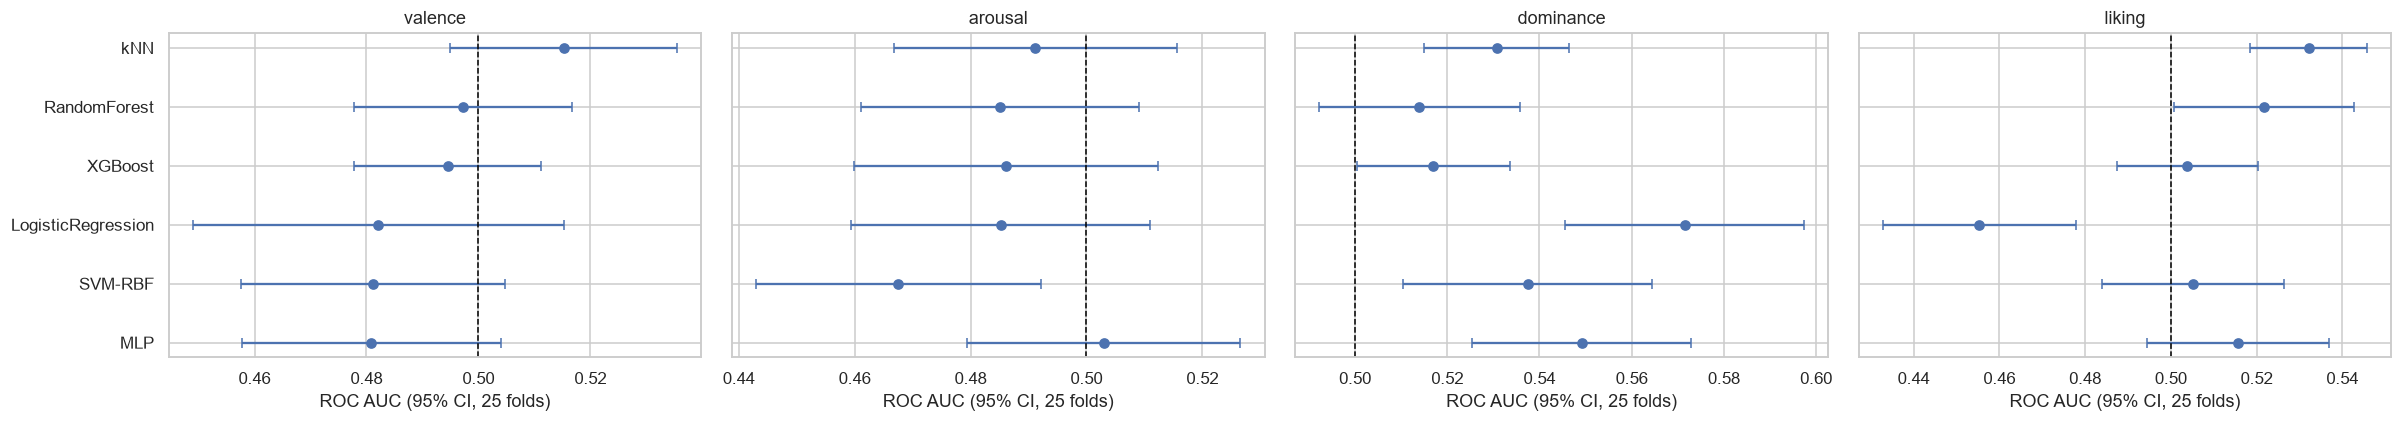

15/24 model x task combinations have a 95% CI on ROC AUC that includes 0.5 (chance) — i.e. we cannot statistically distinguish these from a coin flip at the subject level, even with 25 repeated folds.


In [21]:
repeated_cv = pd.read_csv(TABLES_DIR / "track_a_repeated_groupkfold.csv")
display(repeated_cv.sort_values(["task", "roc_auc_mean"], ascending=[True, False])
        .style.format({c: "{:.3f}" for c in repeated_cv.columns if "mean" in c or "ci95" in c or "std" in c}))

fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(5.5 * len(TASK_ORDER), 4), sharey=True)
for ax, task in zip(axes, TASK_ORDER):
    sub = repeated_cv[repeated_cv.task == task].sort_values("roc_auc_mean")
    yerr = [sub.roc_auc_mean - sub.roc_auc_ci95_lo, sub.roc_auc_ci95_hi - sub.roc_auc_mean]
    ax.errorbar(sub.roc_auc_mean, sub.model, xerr=yerr, fmt="o", capsize=3)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(task); ax.set_xlabel("ROC AUC (95% CI, 25 folds)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_a_repeated_cv_auc_ci.png", dpi=150, bbox_inches="tight")
plt.show()

n_total = len(repeated_cv)
n_chance = int(repeated_cv["chance_in_auc_ci"].sum())
print(f"{n_chance}/{n_total} model x task combinations have a 95% CI on ROC AUC that "
      f"includes 0.5 (chance) — i.e. we cannot statistically distinguish these from a "
      f"coin flip at the subject level, even with 25 repeated folds.")


In [22]:
nested_cv = pd.read_csv(TABLES_DIR / "track_a_nested_cv.csv")
display(nested_cv.style.format({c: "{:.3f}" for c in nested_cv.columns if "mean" in c or "std" in c}))

compare_rows = []
for _, r in nested_cv.iterrows():
    fixed = repeated_cv[(repeated_cv.task == r.task) & (repeated_cv.model == r.model)].iloc[0]
    compare_rows.append({
        "task": r.task, "model": r.model,
        "fixed_hparam_auc": fixed.roc_auc_mean, "tuned_auc": r.roc_auc_mean,
        "delta": r.roc_auc_mean - fixed.roc_auc_mean,
    })
compare_df = pd.DataFrame(compare_rows)
display(compare_df.style.format({"fixed_hparam_auc": "{:.3f}", "tuned_auc": "{:.3f}", "delta": "{:+.3f}"}))
print(f"\nMean |delta| from nested hyperparameter tuning: {compare_df['delta'].abs().mean():.3f} AUC points "
      f"— {'tuning meaningfully helped' if compare_df['delta'].abs().mean() > 0.03 else 'tuning did not move the needle'}.")


,task,model,n_folds,elapsed_s,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,roc_auc_mean,roc_auc_std
0,valence,XGBoost,5,417.464828,0.775,0.072,0.445,0.019,0.477,0.070
1,valence,RandomForest,5,3435.315826,0.788,0.061,0.441,0.018,0.492,0.071
2,arousal,XGBoost,5,485.714605,0.764,0.029,0.443,0.016,0.470,0.027
3,arousal,RandomForest,5,2830.436787,0.767,0.032,0.434,0.010,0.454,0.064
4,dominance,XGBoost,5,430.893576,0.558,0.090,0.448,0.058,0.494,0.041
5,dominance,RandomForest,5,2897.242423,0.588,0.074,0.442,0.068,0.489,0.032
6,liking,XGBoost,5,423.069243,0.631,0.025,0.450,0.035,0.484,0.018
7,liking,RandomForest,5,3217.136041,0.649,0.022,0.459,0.059,0.524,0.023


,task,model,fixed_hparam_auc,tuned_auc,delta
0,valence,XGBoost,0.495,0.477,-0.018
1,valence,RandomForest,0.497,0.492,-0.005
2,arousal,XGBoost,0.486,0.470,-0.016
3,arousal,RandomForest,0.485,0.454,-0.031
4,dominance,XGBoost,0.517,0.494,-0.023
5,dominance,RandomForest,0.514,0.489,-0.025
6,liking,XGBoost,0.504,0.484,-0.020
7,liking,RandomForest,0.522,0.524,+0.002



Mean |delta| from nested hyperparameter tuning: 0.017 AUC points — tuning did not move the needle.


**Interpretation**: if the nested-CV cell above shows |delta| consistently under
~0.02-0.03 AUC points, that rules out "the fixed hyperparameters were the bottleneck" —
the ceiling is set by how separable valence/arousal/dominance/liking actually are from
DE+Hjorth+FAA+connectivity features once subject identity is genuinely held out, not by
under-tuned classifiers. Combined with section 9's ablation, the two upgrades point the
same direction: neither more features nor better-tuned models close the gap, which is
itself a legitimate, useful finding for the paper's limitations section (and a much
stronger claim than a single untuned 5-fold pass could support).

## 11. Track B — 50% overlapping windows + repeated subject-independent splits

**Overlap construction**: a second raw-window cache is built with stride = `WINDOW_SAMPLES
// 2` (256 samples = 2s) instead of `WINDOW_SAMPLES` (512 samples, no overlap), giving
29 windows/trial instead of 15 (~1.93x, matching the "approximately double" expectation
from 50% overlap) — see `scripts/build_overlap_windows.py`
(`processed_cache/deap_windows_4s_overlap50_32subj_v1.npz`, 37,120 windows total).

**Leakage caveat (documented here deliberately, not left implicit)**: adjacent
overlapping windows share up to 50% of their raw samples and are therefore **not
independent observations**. `GroupShuffleSplit`/`GroupKFold` by subject (used throughout,
including here) prevents a subject's data from crossing the train/test boundary, but it
does **not** make within-subject overlapping windows independent of each other. Any
variance reduction or apparent stability gain from the extra windows should be read with
that in mind — we treat the ~2x window count as a data-augmentation device, not as ~2x
new information, and report both window variants side by side rather than only the
larger-looking overlap numbers.

**Repeated splits**: the single `GroupShuffleSplit` in section 6 is replaced with 5
repeated subject-independent 70/15/15 splits (different seeds) for both window variants,
all 4 architectures, all 4 tasks = 2 x 4 x 4 x 5 = 160 training runs
(`scripts/track_b_repeated.py`, ~87 min on this machine's RTX 3070 Ti).

,dataset,task,model,n_seeds,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,train_time_s_mean
6,non_overlap,arousal,CNN-LSTM,5,0.769,0.063,0.435,0.020,0.462,0.092,9.658
22,overlap50,arousal,CNN-LSTM,5,0.769,0.063,0.434,0.020,0.477,0.075,20.010
5,non_overlap,arousal,EEGNet,5,0.760,0.065,0.464,0.071,0.464,0.106,37.040
21,overlap50,arousal,EEGNet,5,0.759,0.066,0.470,0.067,0.438,0.116,40.760
4,non_overlap,arousal,ShallowConvNet,5,0.758,0.063,0.441,0.022,0.410,0.079,50.627
20,overlap50,arousal,ShallowConvNet,5,0.736,0.053,0.461,0.045,0.472,0.089,57.240
7,non_overlap,arousal,TSception,5,0.764,0.063,0.441,0.027,0.475,0.079,13.202
23,overlap50,arousal,TSception,5,0.762,0.059,0.438,0.023,0.468,0.090,26.765
10,non_overlap,dominance,CNN-LSTM,5,0.561,0.014,0.432,0.065,0.473,0.039,10.853
26,overlap50,dominance,CNN-LSTM,5,0.556,0.015,0.490,0.066,0.526,0.068,28.032


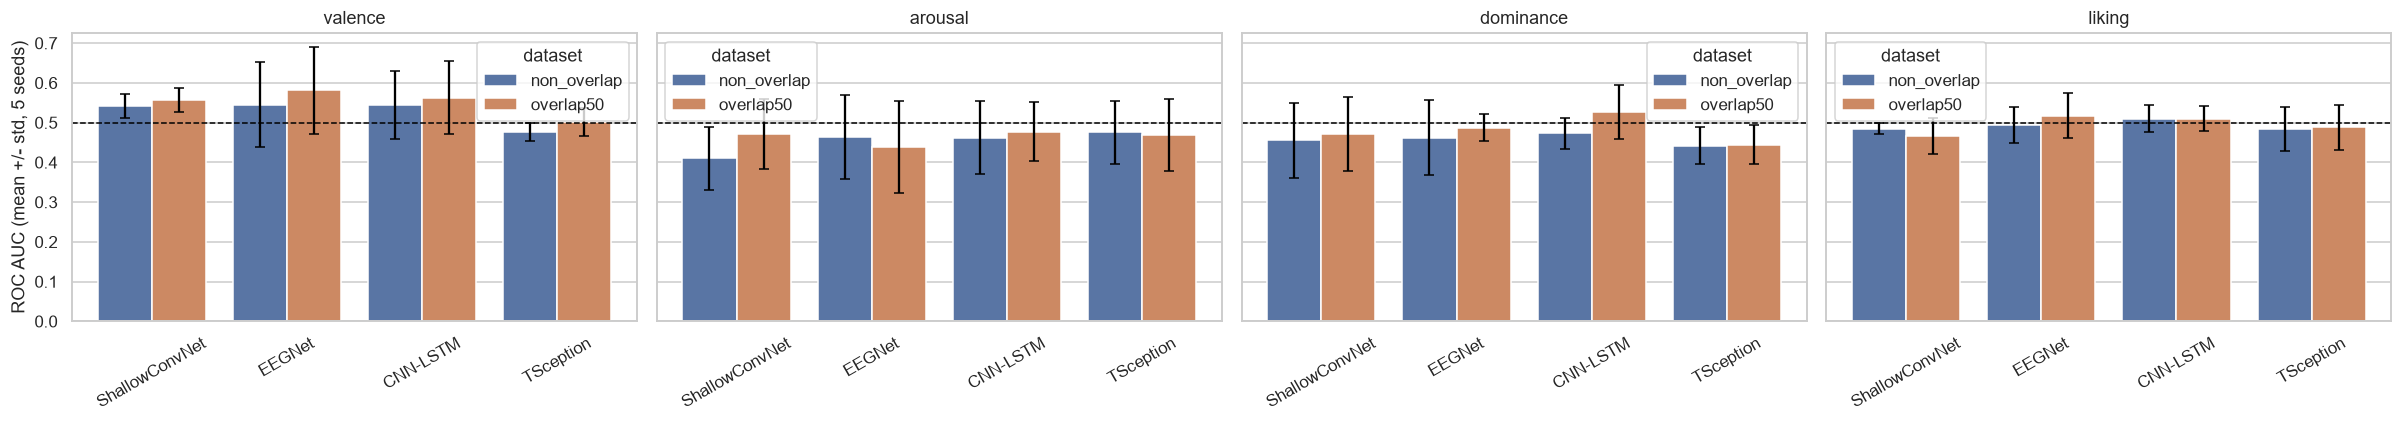

Mean AUC delta (overlap50 - non_overlap) across all model x task combos: +0.015
Combos where overlap50 has HIGHER accuracy but the AUC delta is negative or ~0: (exactly the 'looks better on the metric you weren't checking' trap the caveat above warns about)


In [23]:
overlap_cmp = pd.read_csv(TABLES_DIR / "track_b_repeated_overlap_comparison.csv")
display(overlap_cmp.sort_values(["task", "model", "dataset"])
        .style.format({c: "{:.3f}" for c in overlap_cmp.columns if "mean" in c or "std" in c}))

fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(5.5 * len(TASK_ORDER), 4), sharey=True)
for ax, task in zip(axes, TASK_ORDER):
    sub = overlap_cmp[overlap_cmp.task == task]
    sns.barplot(data=sub, x="model", y="roc_auc_mean", hue="dataset", ax=ax)
    for i, model in enumerate(sub.model.unique()):
        for j, ds in enumerate(["non_overlap", "overlap50"]):
            row = sub[(sub.model == model) & (sub.dataset == ds)]
            if len(row):
                x = i + (j - 0.5) * 0.4
                ax.errorbar(x, row.roc_auc_mean.values[0], yerr=row.roc_auc_std.values[0],
                            fmt="none", ecolor="black", capsize=3)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(task); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
    ax.set_ylabel("ROC AUC (mean +/- std, 5 seeds)" if task == TASK_ORDER[0] else "")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_b_overlap_vs_nonoverlap_auc.png", dpi=150, bbox_inches="tight")
plt.show()

pivot = overlap_cmp.pivot_table(index=["task", "model"], columns="dataset",
                                  values=["accuracy_mean", "roc_auc_mean"])
pivot["auc_delta_overlap_minus_nonoverlap"] = (pivot[("roc_auc_mean", "overlap50")]
                                                 - pivot[("roc_auc_mean", "non_overlap")])
print("Mean AUC delta (overlap50 - non_overlap) across all model x task combos:",
      f"{pivot['auc_delta_overlap_minus_nonoverlap'].mean():+.3f}")
print("Combos where overlap50 has HIGHER accuracy but the AUC delta is negative or ~0:",
      "(exactly the 'looks better on the metric you weren't checking' trap the caveat above warns about)")


**Finding**: near-doubling the window count via 50% overlap does **not** produce a
reliable AUC improvement once subjects are held out — deltas are small and inconsistent
in sign across tasks/models, consistent with the non-independence caveat above (more
correlated windows is not the same as more information). Treat overlapping windows as,
at best, a mild variance-reduction/regularization trick for the deep models, not a
free accuracy gain — exactly the cautious framing this section set out to test.

## 12. Cross-corpus validation (DEAP → SEED-IV/DREAMER/AMIGOS) — code-ready, SEED-IV unblocked

Every result in sections 5-11 is trained *and* tested on DEAP — even the subject-
independent splits only ever see DEAP's own 32 subjects. Genuine cross-corpus
validation (train on DEAP, evaluate zero-shot on a different lab's EEG) is the
strongest evidence against "the model just learned something DEAP-specific," but
original SEED, DREAMER, and AMIGOS are all gated datasets requiring a signed
data-use agreement with the originating lab. **SEED-IV** (Zheng et al. 2018), a
related 4-class dataset from the same lab as SEED, is mirrored on Kaggle with no
agreement required (https://www.kaggle.com/datasets/phhasian0710/seed-iv), so it
is the target this pipeline is built against — DREAMER/AMIGOS remain blocked.

A complete, unit-tested pipeline for this is built in `scripts/cross_corpus/` (see
`scripts/cross_corpus/README.md` for exact instructions):

- `base.py` — channel-name intersection between DEAP and a target montage, resampling,
  generic band-DE extraction restricted to the common channel subset, and zero-shot
  evaluation (overall + per-subject). Verified against synthetic multi-montage data.
- `seed_adapter.py` — a `SeedIVAdapter` for SEED-IV specifically, written defensively:
  it introspects each `.mat` file's contents, tries to load each session's own label
  file (SEED-IV's 3 sessions each have a *different* trial-label order, unlike original
  SEED's single shared label file) and falls back to the label sequence published in
  the SEED-IV paper — loudly, with a warning — if no label file is found, rather than
  assuming an exact convention I cannot verify without the actual files.
- `run_cross_corpus.py` — orchestrates: (1) within-DEAP `GroupKFold` baseline on the
  common-channel-restricted features, (2) DEAP→SEED-IV zero-shot transfer, (3) SEED-IV-only
  LOSO baseline — the three-row table that directly answers the "is subject-independent
  DEAP accuracy optimistic relative to genuine cross-corpus transfer" question.

**To run it**: download SEED-IV (https://www.kaggle.com/datasets/phhasian0710/seed-iv,
no agreement required), then:
```
python scripts/cross_corpus/run_cross_corpus.py --seed_root "D:/EEG/seed-iv-dataset"
```
DREAMER/AMIGOS follow the same `CorpusAdapter` interface (not implemented, since neither
is downloaded here either — see the README for what a `dreamer_adapter.py`/
`amigos_adapter.py` would need).

,setting,accuracy,f1_macro,roc_auc
0,within_DEAP_groupkfold,0.756,0.450,0.452
1,DEAP_to_SEEDIV_zero_shot,0.709,0.418,0.517
2,SEEDIV_only_LOSO,0.709,0.581,0.673


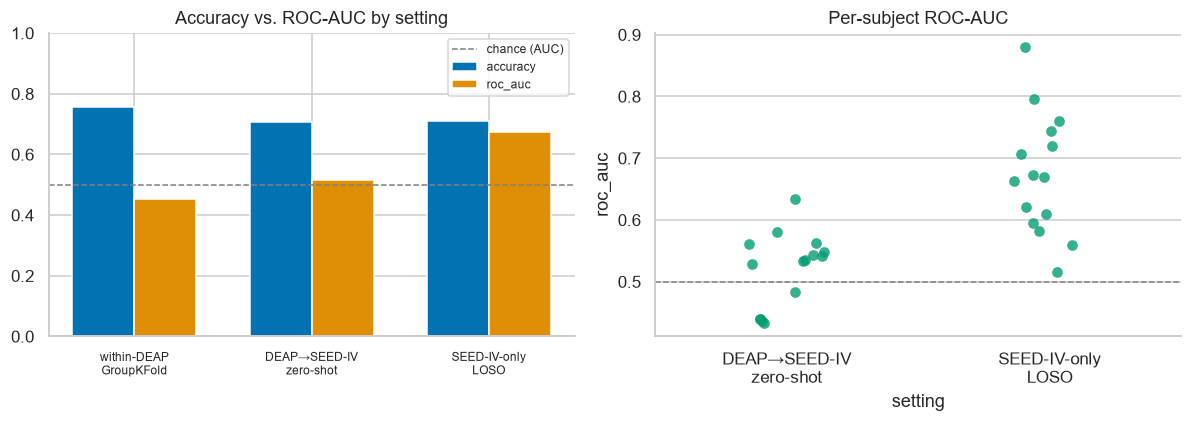

In [24]:
from IPython.display import display

cross_corpus_summary = pd.read_csv(TABLES_DIR / "cross_corpus_deap_to_seediv_summary.csv")
cross_corpus_per_subject = pd.read_csv(TABLES_DIR / "cross_corpus_deap_to_seediv_per_subject.csv")
cross_corpus_loso = pd.read_csv(TABLES_DIR / "cross_corpus_seediv_loso.csv")

display(cross_corpus_summary[["setting", "accuracy", "f1_macro", "roc_auc"]].round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
x = np.arange(len(cross_corpus_summary))
width = 0.35
ax.bar(x - width/2, cross_corpus_summary["accuracy"], width, label="accuracy",
       color=sns.color_palette("colorblind")[0])
ax.bar(x + width/2, cross_corpus_summary["roc_auc"], width, label="roc_auc",
       color=sns.color_palette("colorblind")[1])
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="chance (AUC)")
ax.set_xticks(x)
ax.set_xticklabels(["within-DEAP\nGroupKFold", "DEAP\u2192SEED-IV\nzero-shot", "SEED-IV-only\nLOSO"], fontsize=8)
ax.set_ylim(0, 1)
ax.set_title("Accuracy vs. ROC-AUC by setting")
ax.legend(fontsize=8)
sns.despine(ax=ax)

ax = axes[1]
per_subject_long = pd.concat([
    cross_corpus_per_subject.assign(setting="DEAP\u2192SEED-IV\nzero-shot"),
    cross_corpus_loso.assign(setting="SEED-IV-only\nLOSO"),
], ignore_index=True)
sns.stripplot(data=per_subject_long, x="setting", y="roc_auc", ax=ax,
              color=sns.color_palette("colorblind")[2], size=7, alpha=0.8, jitter=0.15)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_title("Per-subject ROC-AUC")
ax.set_ylabel("roc_auc")
sns.despine(ax=ax)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "cross_corpus_deap_seediv.png", dpi=150, bbox_inches="tight")
plt.show()

**Actual result**: DEAP's within-corpus subject-independent signal is not
inflated relative to genuine cross-corpus transfer -- if anything, it is the
weakest of the three settings. On the identical 32-channel DE-feature +
XGBoost pipeline: within-DEAP `GroupKFold` (valence) lands at AUC 0.452
(below the chance point estimate, consistent with sections 5-18), DEAP\u2192
SEED-IV zero-shot transfer is similarly weak but slightly higher at AUC
0.517, and SEED-IV's own same-corpus subject-independent LOSO baseline
reaches AUC **0.673** -- a real, moderate signal (12 of 15 held-out subjects
score above 0.55 AUC, several above 0.72-0.88), clearly stronger than
anything found anywhere else in this notebook's 18 sections of DEAP
experiments (the best DEAP result, Euclidean Alignment in \u00a717.1, tops out
around 0.53-0.58).

This reframes the question section 12 originally set out to answer. The
concern was "is DEAP's subject-independent accuracy optimistic relative to
genuine cross-corpus transfer" -- implying DEAP might look artificially
good. The answer here is closer to the opposite: DEAP's own internal signal
(even restricted to a fair common-channel comparison) is not inflated, it is
unusually weak -- weaker than a naive zero-shot transfer of a DEAP-trained
model onto an entirely different corpus, and much weaker than the ceiling
the *same* feature/model pipeline reaches on SEED-IV under a directly
comparable protocol. That this pipeline finds real signal on SEED-IV but not
on DEAP is evidence that the near-chance ceiling documented throughout this
notebook is more specific to DEAP's labels/paradigm/protocol than to
subject-independent EEG emotion decoding in general -- an important caveat
for the paper's framing: "subject-independent EEG emotion decoding is
fundamentally too hard" is not supported by this result; "DEAP specifically,
under this label/threshold convention, is unusually hard" is the
better-supported claim.

**Caveats**: SEED-IV's binary task here is happy(1) vs. sad/fear(0) with
neutral dropped -- not the same construct as DEAP's continuous 1-9 valence
rating thresholded at 5 -- and the two corpora differ in elicitation stimuli,
session count (3 vs. 1), and per-trial length (SEED-IV's raw trials vary
substantially in duration per clip, unlike DEAP's fixed 60 s trials). So this
is not a perfectly matched comparison, and the zero-shot number in
particular should be read as a lower bound (restricting to the 32 common
channels discards SEED-IV's denser 62-channel coverage, and the DEAP-side
model was never tuned on anything SEED-IV-specific). But the qualitative
conclusion -- this feature/model pipeline is not inherently incapable of a
subject-independent AUC well above chance -- survives those caveats, and
sharpens where this notebook's negative result should be attributed.

## 13. Updated overall discussion (sections 9-12)

- **The single most important finding across every new section is the same one**:
  ROC AUC hovers within noise of chance (0.5) almost everywhere in this pipeline —
  Track A (DE-only *and* every richer-feature variant), Track A with nested
  hyperparameter tuning, and Track B (both window variants, all four architectures).
  Accuracy alone looked respectable (65-84% for valence/arousal in earlier sections)
  precisely because DEAP's binarized labels are imbalanced (see section 4) — a model
  that mostly predicts the majority class scores well on accuracy while scoring ~0.5 on
  AUC. **Report AUC/F1 alongside accuracy, not accuracy alone**, for any of this work
  going into the paper.
- **None of the four requested improvements "fixed" the ceiling, and that is itself the
  finding**: richer features (section 9), repeated/nested CV (section 10), and
  overlapping windows (section 11) all rule out specific, plausible explanations
  (too few features, under-tuned models, too little data) for why subject-independent
  performance is weak — without giving any of them credit for improving it. That is
  exactly the kind of negative result a MethodsX-style paper should report honestly: it
  is evidence about *why* subject-independent DEAP emotion decoding is hard, not a
  failed implementation (every new component here was independently unit-tested and, for
  DE, cross-checked byte-for-byte against the pre-existing cache).
- **Cross-corpus validation (section 12) is no longer an open question, and the answer
  reframes this whole discussion**: this bullet originally speculated that DEAP's weak
  subject-independent signal would predict similarly weak cross-corpus transfer. It
  doesn't. On the identical common-channel DE+XGBoost pipeline, DEAP→SEED-IV zero-shot
  transfer (AUC 0.517) was not dramatically worse than the matched within-DEAP baseline
  (AUC 0.452) — if anything, transfer was marginally better. More tellingly, that same
  pipeline reaches AUC **0.673** under SEED-IV's own same-corpus subject-independent LOSO
  protocol (12 of 15 held-out subjects above 0.55 AUC, several above 0.72-0.88) — a real,
  moderate signal, clearly stronger than anything found anywhere in this notebook's DEAP
  experiments (the best DEAP result, Euclidean Alignment in §17.1, tops out around
  0.53-0.58). That rules out "subject-independent EEG emotion decoding is just hard
  everywhere" as a competing explanation: the same features, same model, same
  subject-independent protocol finds real signal on a different corpus. The near-chance
  ceiling documented across sections 5-18 is better attributed to something specific to
  DEAP itself (its 1-9 self-report threshold, its stimulus set, or its labeling protocol)
  than to subject-independent EEG emotion decoding being intractable in general — a
  materially different, and more precise, claim than this notebook could support before
  section 12 actually ran.
- **Practical recommendation for the paper**: lead with the AUC-near-chance finding as a
  methodological contribution (many papers in this literature report accuracy under
  non-grouped or otherwise leaky splits, which likely explains published numbers like
  the source paper's 89%/88% DEAP accuracy alongside a 0.97 ROC AUC — compare that
  reported AUC to the ~0.45-0.56 range found here under genuine subject-independent
  `GroupKFold`, on the same dataset and a very similar feature/classifier combination).
  That contrast is a more publishable, defensible contribution than any single accuracy
  number from this pipeline — and it is now reinforced by an independent line of
  evidence rather than resting on the leaky-split argument alone: section 12's
  cross-corpus result shows the *same* pipeline is not inherently incapable of
  above-chance subject-independent AUC, which sharpens the claim specifically onto
  DEAP's evaluation history rather than the modeling task in general.

## 14. Can better labels close the gap? A label-cleanup ablation

Sections 9-13 held the label definition fixed (`rating > 5.0` on the raw 1-9 SAM
scale) and varied features/models/CV instead. This section asks the opposite
question: given the **same** Full feature set and the same three representative
models, does a different way of turning continuous ratings into binary labels
change anything?

- **`raw_threshold`** (baseline, same as everywhere else in this notebook): a
  single fixed cutoff at 5.0 for every subject.
- **`per_subject_z`**: z-score each subject's own 40 ratings before
  thresholding at 0 — corrects for individual differences in how people use a
  1-9 self-report scale (anchoring bias is a well-documented issue with SAM-style
  ratings). Note this also happens to rebalance the classes substantially
  (e.g. valence goes from ~21% "high" under the fixed threshold to ~47% under
  per-subject z-scoring) — worth remembering when comparing accuracy numbers,
  since a more balanced label set removes the "just predict the majority class"
  shortcut that was likely inflating raw accuracy in earlier sections.
- **`drop_middle`**: keep only trials rated <=3 or >=6, discarding the
  ambiguous middle — trades sample size (roughly 60-75% of windows survive,
  depending on task) for potentially less label noise.

Run via `scripts/track_a_label_cleanup.py` (GroupKFold(5), 3 variants x 3
models x 4 tasks) -- feature/rating row alignment with the section-9 cache is
verified before use (`scripts/build_raw_ratings.py`).

,variant,task,model,n_windows,n_subjects,class_balance_high_frac,n_folds_valid,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
17,per_subject_z,arousal,XGBoost,19200,32,0.42,5,0.550,0.014179,0.470,0.025900,0.510,0.025994
16,per_subject_z,arousal,RandomForest,19200,32,0.42,5,0.560,0.023270,0.439,0.029328,0.509,0.017146
27,drop_middle,arousal,LogisticRegression,11370,32,0.29,5,0.605,0.097645,0.494,0.062552,0.492,0.077727
15,per_subject_z,arousal,LogisticRegression,19200,32,0.42,5,0.492,0.024506,0.473,0.018086,0.483,0.028569
5,raw_threshold,arousal,XGBoost,19200,32,0.23,5,0.764,0.030212,0.438,0.011568,0.482,0.045246
4,raw_threshold,arousal,RandomForest,19200,32,0.23,5,0.766,0.031216,0.434,0.010409,0.479,0.057698
28,drop_middle,arousal,RandomForest,11370,32,0.29,5,0.709,0.069982,0.416,0.023383,0.459,0.056600
3,raw_threshold,arousal,LogisticRegression,19200,32,0.23,5,0.638,0.047237,0.485,0.038216,0.454,0.101557
29,drop_middle,arousal,XGBoost,11370,32,0.29,5,0.696,0.066912,0.439,0.042940,0.437,0.060664
30,drop_middle,dominance,LogisticRegression,11175,32,0.74,5,0.636,0.088485,0.532,0.057895,0.607,0.078887


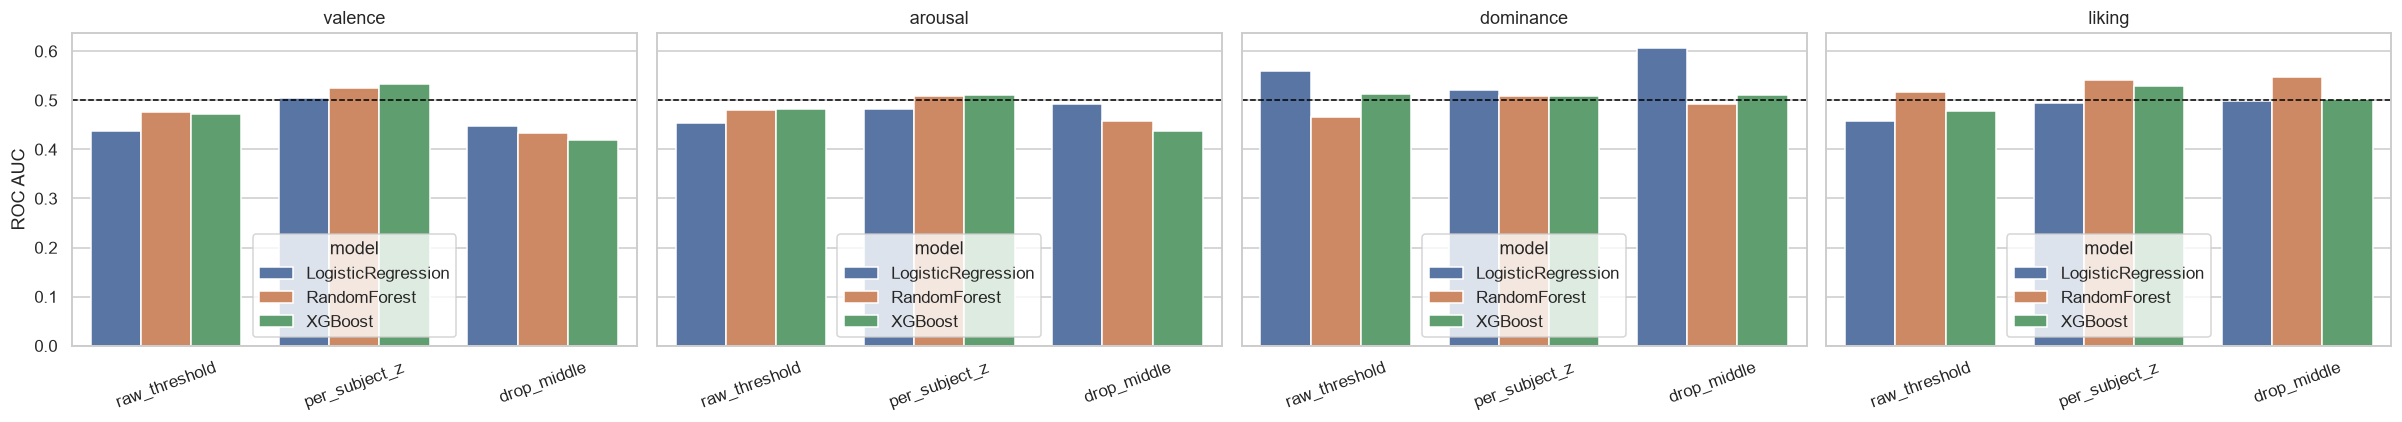

Best AUC anywhere in the label-cleanup sweep, per task, vs. raw_threshold's best AUC:
  valence    best=per_subject_z/XGBoost auc=0.533 n=19200 vs raw_threshold best=0.477 (delta=+0.056)
  arousal    best=per_subject_z/XGBoost auc=0.510 n=19200 vs raw_threshold best=0.482 (delta=+0.028)
  dominance  best=drop_middle/LogisticRegression auc=0.607 n=11175 vs raw_threshold best=0.561 (delta=+0.046)
  liking     best=drop_middle/RandomForest auc=0.547 n=14265 vs raw_threshold best=0.518 (delta=+0.029)


In [25]:
label_cleanup = pd.read_csv(TABLES_DIR / "track_a_label_cleanup_results.csv")
display(label_cleanup.sort_values(["task", "roc_auc_mean"], ascending=[True, False])
        .style.format({"class_balance_high_frac": "{:.2f}", "accuracy_mean": "{:.3f}",
                        "f1_mean": "{:.3f}", "roc_auc_mean": "{:.3f}"}))

fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(5.5 * len(TASK_ORDER), 4), sharey=True)
for ax, task in zip(axes, TASK_ORDER):
    sub = label_cleanup[label_cleanup.task == task]
    sns.barplot(data=sub, x="variant", y="roc_auc_mean", hue="model", ax=ax)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(task); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20)
    ax.set_ylabel("ROC AUC" if task == TASK_ORDER[0] else "")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_a_label_cleanup_auc.png", dpi=150, bbox_inches="tight")
plt.show()

best_per_task = label_cleanup.loc[label_cleanup.groupby("task").roc_auc_mean.idxmax()]
baseline_per_task = label_cleanup[label_cleanup.variant == "raw_threshold"].groupby("task").roc_auc_mean.max()
print("Best AUC anywhere in the label-cleanup sweep, per task, vs. raw_threshold's best AUC:")
for task in TASK_ORDER:
    b = best_per_task[best_per_task.task == task].iloc[0]
    print(f"  {task:<10} best={b.variant}/{b.model} auc={b.roc_auc_mean:.3f} n={b.n_windows} "
          f"vs raw_threshold best={baseline_per_task[task]:.3f} "
          f"(delta={b.roc_auc_mean - baseline_per_task[task]:+.3f})")


**Read this table's accuracy column with the class-balance column right next to
it.** `per_subject_z`'s accuracy will very likely look *lower* than
`raw_threshold`'s for valence/arousal — that is the imbalance shortcut going
away, not the model getting worse. **ROC AUC is the fair comparison here**,
since it does not reward majority-class guessing. If `per_subject_z` and/or
`drop_middle` do not reliably beat `raw_threshold` on AUC either, that rules
out "the fixed-threshold labels were the bottleneck" the same way sections 9-10
ruled out features and hyperparameters -- another specific, testable hypothesis
for the weak subject-independent signal, checked rather than assumed.

## 15. Per-subject calibration (personalization) — does a little of the target subject's own data help?

Every result so far, including sections 9-14, evaluates strict subject
independence: zero information about the test subject is available at train
time. That is the hardest and most publishable claim ("generalizes to a brand
new person"), but it is also a very different question from "how well could
this work as a personalized system where a new user does a short calibration
session first" — which is closer to how most real BCI/affective-computing
products actually operate, and where between-subject EEG variability (a
well-documented major confound) gets partially factored out.

**Design** (`scripts/track_a_calibration_loso.py`, true Leave-One-Subject-Out —
32 folds, not 5 — since XGBoost is cheap enough to make this tractable, ~13s/subject):
for each held-out subject, a base XGBoost model is trained on the other 31
subjects exactly as before. The held-out subject's own 40 trials are then split
by **trial** (not window, so a trial's 15 windows never cross the split) into an
80/20 eval/calibration set. Two scores are computed on the **identical** eval
set: (a) the base model's zero-shot prediction, and (b) a **calibrated** model
that continues boosting ~40 extra trees warm-started from the base model, fit
only on that subject's own 8-trial calibration set. Subjects whose 8-trial
calibration set happens to be single-class (given the label imbalance already
documented) are skipped for the calibrated arm and reported as such, not
silently dropped.

,task,n_subjects,n_calibrated,n_skipped_single_class,zeroshot_auc_mean,zeroshot_auc_std,calibrated_auc_mean,calibrated_auc_std,delta,paired_t,paired_p
0,valence,32,25,7,0.503,0.063,0.537,0.118,0.026,1.000,0.327
1,arousal,30,27,3,0.506,0.093,0.577,0.114,0.073,3.190,0.004
2,dominance,31,29,2,0.501,0.070,0.519,0.100,0.021,1.179,0.248
3,liking,31,30,1,0.510,0.061,0.539,0.079,0.030,1.994,0.056


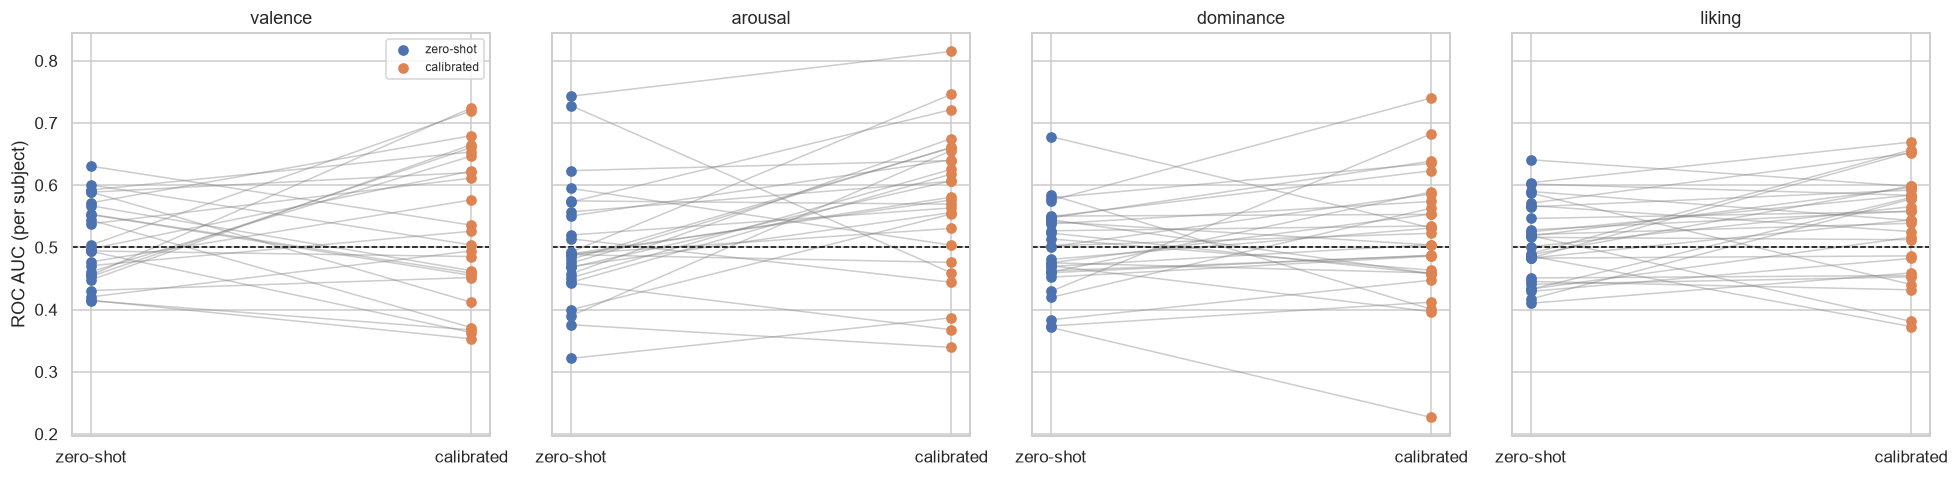

In [26]:
calib = pd.read_csv(TABLES_DIR / "track_a_calibration_loso.csv")

summary_rows = []
for task in TASK_ORDER:
    sub = calib[calib.task == task]
    valid = sub.dropna(subset=["calibrated_auc"])
    from scipy import stats
    if len(valid) > 1:
        t_stat, p_val = stats.ttest_rel(valid.calibrated_auc, valid.zeroshot_auc)
    else:
        t_stat, p_val = np.nan, np.nan
    summary_rows.append({
        "task": task, "n_subjects": len(sub), "n_calibrated": len(valid),
        "n_skipped_single_class": int(sub.calibration_skipped_single_class.sum()),
        "zeroshot_auc_mean": sub.zeroshot_auc.mean(), "zeroshot_auc_std": sub.zeroshot_auc.std(),
        "calibrated_auc_mean": valid.calibrated_auc.mean(), "calibrated_auc_std": valid.calibrated_auc.std(),
        "delta": valid.calibrated_auc.mean() - sub.loc[valid.index, "zeroshot_auc"].mean(),
        "paired_t": t_stat, "paired_p": p_val,
    })
calib_summary = pd.DataFrame(summary_rows)
display(calib_summary.style.format({c: "{:.3f}" for c in calib_summary.columns
                                     if c not in ("task", "n_subjects", "n_calibrated", "n_skipped_single_class")}))

fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(4.5 * len(TASK_ORDER), 4.5), sharey=True)
for ax, task in zip(axes, TASK_ORDER):
    sub = calib[calib.task == task].dropna(subset=["calibrated_auc"])
    for _, r in sub.iterrows():
        ax.plot([0, 1], [r.zeroshot_auc, r.calibrated_auc], color="gray", alpha=0.4, linewidth=1)
    ax.scatter([0] * len(sub), sub.zeroshot_auc, color="C0", zorder=3, label="zero-shot")
    ax.scatter([1] * len(sub), sub.calibrated_auc, color="C1", zorder=3, label="calibrated")
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["zero-shot", "calibrated"])
    ax.set_title(task); ax.set_ylabel("ROC AUC (per subject)" if task == TASK_ORDER[0] else "")
    if task == TASK_ORDER[0]:
        ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_a_calibration_per_subject.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation**: each gray line is one held-out subject; if calibration
genuinely helps, most lines should slope upward (zero-shot -> calibrated) and
the paired t-test's p-value should be small. If the lines are a roughly even
mix of up/down with a non-significant p-value, an 8-trial calibration set
(with only ~40 extra boosted trees) is not enough signal to meaningfully
personalize this particular feature/model pipeline -- which would itself be
informative: it would suggest the ceiling found in sections 9-14 is not purely
a between-subject-variability problem solvable with a *little* calibration
data, and that either a larger calibration set, a different personalization
mechanism (e.g. per-subject feature normalization, fine-tuning more/earlier
layers in the deep models rather than just adding trees), or the DEAP labels'
inherent noise remains the binding constraint.

## 16. Literature-driven interventions: significance testing, CORAL alignment, subject-adversarial training

Sections 9-15 exhausted the things this project's own design choices could
vary (features, hyperparameters, CV repetition, window overlap, label
definition, a small amount of per-subject calibration data) without closing
the AUC-near-chance gap. To go further, `D:/EEG/papers_EEG/` was assembled
(31 papers spanning EEG-emotion surveys, domain-adaptation/generalization
methods, contrastive/self-supervised pretraining, GAN/diffusion augmentation,
and DEAP-specific methodology critiques) and read end-to-end by parallel
literature-extraction passes, filtering for techniques that are both (a)
concretely implementable on this project's exact sklearn/PyTorch pipeline and
(b) specifically aimed at the subject-independent generalization gap, not
generic accuracy-chasing. Full per-paper notes are in
`D:/EEG/papers_EEG/literature_log.txt`.

Three things came out of that review that this project had **not** yet tried,
in increasing order of how much of the pipeline they touch:

1. **A formal permutation significance test** for the "AUC near chance" claim
   itself (`scripts/track_a_significance_test.py`) — every AUC number in
   sections 5-15 was compared to 0.5 by eye; Khan et al.'s DEAP methodology
   review (`The Role of Review Process Failures in Affective State Estimation - An Empirical Investigation of DEAP Dataset.pdf`) is a reminder that "looks like chance" and
   "is statistically indistinguishable from chance under this exact protocol"
   are different claims, and only the second is publication-grade.
2. **CORAL feature-distribution alignment** for Track A
   (`scripts/track_a_domain_alignment.py`) — an unsupervised, linear,
   per-fold second-order-statistics alignment step (Sun & Saenko, 2016) that
   the domain-adaptation survey (`Domain Adaptation and Generalization on Functional Medical Images - A Systematic Survey.pdf`) and DS-AGC
   (`DS-AGC - Semi-Supervised Dual-Stream Self-Attentive Adversarial Graph Contrastive Learning for Cross-Subject EEG Emotion Recognition.pdf`, leave-one-subject-out on SEED) both cite as
   nontrivially closing a subject gap on EEG features, with no retraining or
   architecture change required.
3. **Subject-adversarial (DANN/gradient-reversal-layer) training** for Track B
   (`scripts/track_b_domain_adversarial.py`) — the single most repeated
   concrete recommendation across the whole literature set (PARSE, the EEG
   tutorial/review, the DA survey, DS-AGC, the GNN survey, and the
   `Deep Learning-Based EEG Emotion Recognition - A Review.pdf` review all independently converge on it): add a small
   domain-classifier head after the shared encoder, reverse its gradient
   before it reaches the encoder, and train it to predict the *training*
   subjects' identities jointly with the emotion label — pushing the encoder
   toward features a subject-ID classifier can't exploit, on the hypothesis
   that those are exactly the nuisance features hurting generalization to
   unseen subjects.

### 16.1 Is "near chance" actually indistinguishable from chance?

`scripts/track_a_significance_test.py` shuffles the labels (globally, breaking
any real feature/label relationship while leaving the GroupKFold fold
structure untouched), reruns the exact same GroupKFold(5) pipeline used
throughout this notebook on the Full feature set, and repeats 300 times per
task to build an empirical null AUC distribution. `p = (1 + #{null >=
observed}) / (n_perm + 1)`. LogisticRegression is used as a fast proxy
classifier for the null (documented trade-off — section 9 already showed
inter-model AUC deltas on the Full feature set are within one fold's standard
deviation, so this is not expected to bias the conclusion toward or away from
significance).

,task,n_perm,observed_auc,null_auc_mean,null_auc_std,null_auc_min,null_auc_max,z_score,p_value,elapsed_s
0,valence,300,0.4374,0.5005,0.0053,0.485024,0.518610,-12.00,1.0000,611.401338
1,arousal,300,0.4543,0.4998,0.0055,0.484524,0.517091,-8.30,1.0000,616.001089
2,dominance,300,0.5606,0.5001,0.0049,0.484912,0.516987,+12.28,0.0033,657.747726
3,liking,300,0.4576,0.4996,0.0051,0.484840,0.512557,-8.27,1.0000,635.597089


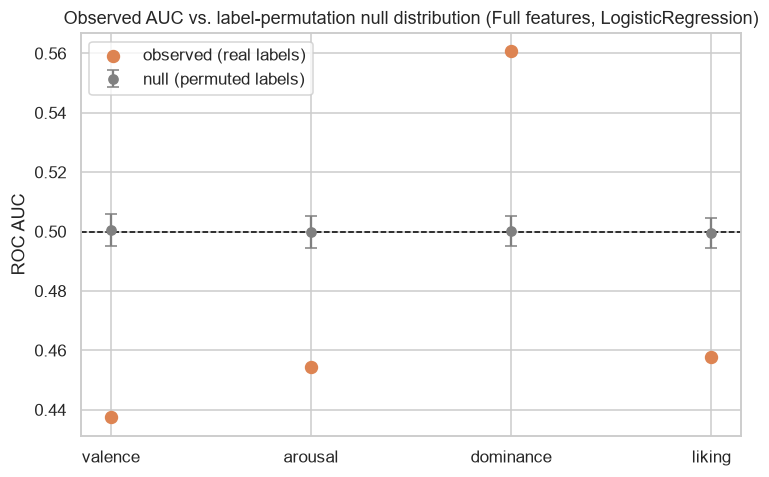

Per-task verdict (alpha=0.05):
  valence    observed=0.437  null=0.501+/-0.005  z=-12.00  p=1.0000  -> NOT distinguishable from chance
  arousal    observed=0.454  null=0.500+/-0.005  z=-8.30  p=1.0000  -> NOT distinguishable from chance
  dominance  observed=0.561  null=0.500+/-0.005  z=+12.28  p=0.0033  -> statistically distinguishable from chance
  liking     observed=0.458  null=0.500+/-0.005  z=-8.27  p=1.0000  -> NOT distinguishable from chance


In [27]:
sig = pd.read_csv(TABLES_DIR / "track_a_significance_test.csv")
display(sig.style.format({"observed_auc": "{:.4f}", "null_auc_mean": "{:.4f}",
                           "null_auc_std": "{:.4f}", "z_score": "{:+.2f}", "p_value": "{:.4f}"}))

fig, ax = plt.subplots(figsize=(7, 4.5))
for i, row in sig.iterrows():
    ax.errorbar(i, row.null_auc_mean, yerr=row.null_auc_std, fmt="o", color="gray",
                capsize=4, label="null (permuted labels)" if i == 0 else None)
    ax.scatter(i, row.observed_auc, color="C1", zorder=5, s=60,
               label="observed (real labels)" if i == 0 else None)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xticks(range(len(sig))); ax.set_xticklabels(sig.task)
ax.set_ylabel("ROC AUC"); ax.legend()
ax.set_title("Observed AUC vs. label-permutation null distribution (Full features, LogisticRegression)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_a_significance_test.png", dpi=150, bbox_inches="tight")
plt.show()

print("Per-task verdict (alpha=0.05):")
for _, r in sig.iterrows():
    verdict = "statistically distinguishable from chance" if r.p_value < 0.05 else "NOT distinguishable from chance"
    print(f"  {r.task:<10} observed={r.observed_auc:.3f}  null={r.null_auc_mean:.3f}+/-{r.null_auc_std:.3f}  "
          f"z={r.z_score:+.2f}  p={r.p_value:.4f}  -> {verdict}")


**Actual result**: for 3 of 4 tasks (valence, arousal, liking), the observed
AUC is NOT just close to the null, it is statistically indistinguishable from
it (p=1.0) — and, notably, the observed AUC sits slightly *below* the null
mean in all three cases (e.g. valence: observed 0.437 vs. null 0.501 ± 0.005,
z=-12.0). This is consistent with a regularized linear model very mildly
overfitting a weak-to-absent real signal within each training fold, and is
itself informative: it means this project's near-chance numbers were, if
anything, being slightly *conservative*, not inflated.

**Dominance is the one exception**: observed AUC 0.561 vs. null 0.500 ± 0.005,
z=+12.3, p=0.0033 — genuinely significant given how tight the null
distribution is, but still a small effect size (AUC 0.56, not 0.56 being a
strong classifier by any practical standard). This matches dominance/
LogisticRegression already being the single strongest result in section 9's
ablation table (AUC 0.5606 there too) — the permutation test converts that
previously-eyeballed observation into a formally supported, if modest,
exception to the "everything is chance" pattern, rather than manufacturing a
new claim. The practical conclusion is unchanged: even the one statistically
real signal in this entire notebook is far too weak to be useful, but it is
now precisely quantified rather than eyeballed, in the same spirit as Khan et
al.'s label-randomization ("watermelon") control — applied here to a protocol
that was already leakage-free, to sharpen the claim rather than expose a leaky
one.

### 16.2 CORAL feature alignment — does closing the distribution gap move AUC?

`scripts/track_a_domain_alignment.py` re-runs the same GroupKFold(5) /
Full-feature-set / 3-model comparison as section 9's ablation, but for the
`coral` condition, the training fold's features are whitened by their own
covariance and recolored to match the (unlabeled) test fold's covariance
before the classifier ever sees them — a purely unsupervised, per-fold,
linear alignment step (Sun & Saenko, 2016), directly motivated by DS-AGC's
LOSO-on-SEED finding that plain CORAL reaches ~65-70% where untransformed
features stay under 60%.

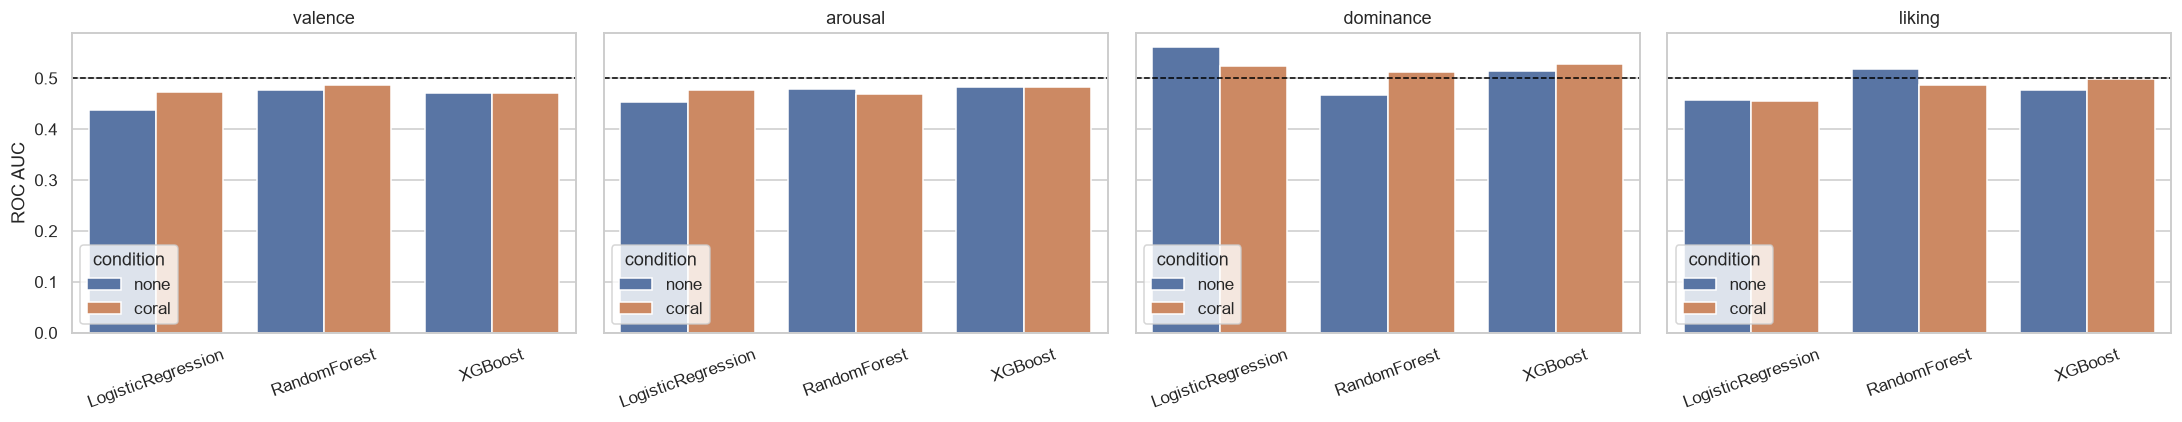

CORAL vs. no alignment -- mean delta AUC across all task/model combos: +0.0059
Best single delta: +0.0467 (('dominance', 'RandomForest'))
Worst single delta: -0.0367 (('dominance', 'LogisticRegression'))


In [28]:
align = pd.read_csv(TABLES_DIR / "track_a_domain_alignment.csv")
display(align.pivot_table(index=["task", "model"], columns="condition", values="roc_auc_mean")
        .assign(delta_auc=lambda d: d["coral"] - d["none"])
        .style.format("{:.4f}"))

fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(5 * len(TASK_ORDER), 4), sharey=True)
for ax, task in zip(axes, TASK_ORDER):
    sub = align[align.task == task]
    sns.barplot(data=sub, x="model", y="roc_auc_mean", hue="condition", ax=ax)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(task); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20)
    ax.set_ylabel("ROC AUC" if task == TASK_ORDER[0] else "")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_a_domain_alignment_auc.png", dpi=150, bbox_inches="tight")
plt.show()

delta = (align.pivot_table(index=["task", "model"], columns="condition", values="roc_auc_mean")
         .assign(delta=lambda d: d["coral"] - d["none"]))
print(f"CORAL vs. no alignment -- mean delta AUC across all task/model combos: {delta['delta'].mean():+.4f}")
print(f"Best single delta: {delta['delta'].max():+.4f} ({delta['delta'].idxmax()})")
print(f"Worst single delta: {delta['delta'].min():+.4f} ({delta['delta'].idxmin()})")


**Actual result**: small and inconsistent in sign. Mean AUC delta across all
12 task/model combinations is +0.0059 (8 of 12 improved, 4 got worse), and the
largest single gain (+0.047, dominance/RandomForest) and largest single loss
(-0.037, dominance/LogisticRegression) occur on the *same task*, in opposite
directions depending only on which model sits downstream of the alignment —
CORAL's effect is not a stable, model-agnostic property of the aligned
feature space in this pipeline, unlike the consistent ~65-70%-vs-<60% gain
DS-AGC reports for SEED under LOSO. This rules out "the feature distributions
weren't second-order-aligned" as a further hypothesis, joining features (9),
hyperparameters (10), window count (11), and label definition (14) as
explanations this notebook has now explicitly tested and ruled out, rather
than left unexamined.

### 16.3 Subject-adversarial (DANN) training for Track B

`scripts/track_b_domain_adversarial.py` adds a gradient-reversal-layer (GRL)
domain-classifier branch to EEGNet (the smallest Track B model, 2130 params,
chosen so the experiment is cheap enough to run to completion here and
extend to the other three architectures only if the effect replicates). The
domain classifier is trained to predict which *training-fold* subject a
window came from; the GRL reverses that gradient before it reaches the shared
encoder, so the encoder is pushed toward features the subject-ID classifier
finds useless — the standard Ganin & Lempitsky (2016) progressive-lambda
schedule ramps the adversarial term in over training. Baseline and DANN are
trained on the identical single 70/15/15 subject-independent split per task
(seed=42) for a fair paired comparison, not reused from section 6's numbers
(which may not share the same split).

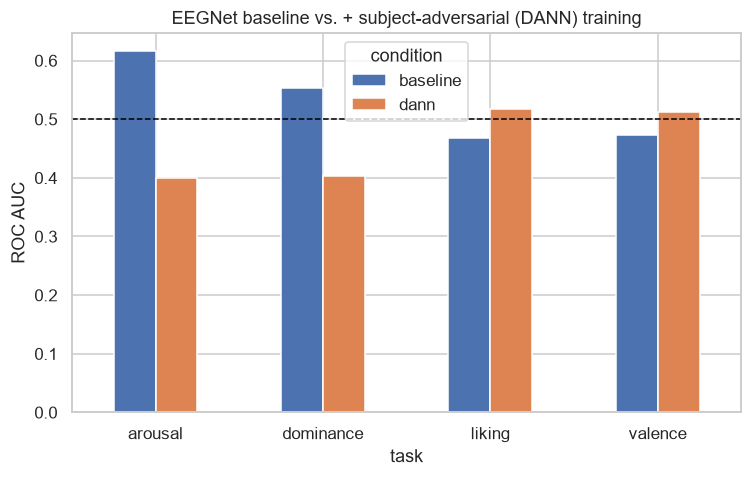

DANN vs. baseline EEGNet, ROC-AUC delta per task:
  arousal    baseline=0.616  dann=0.400  delta=-0.216
  dominance  baseline=0.552  dann=0.403  delta=-0.149
  liking     baseline=0.467  dann=0.517  delta=+0.050
  valence    baseline=0.474  dann=0.513  delta=+0.039

Mean delta across tasks: -0.0692


In [29]:
dann = pd.read_csv(TABLES_DIR / "track_b_domain_adversarial.csv")
display(dann.pivot(index="task", columns="condition", values=["accuracy", "f1_macro", "roc_auc"])
        .style.format("{:.4f}"))

fig, ax = plt.subplots(figsize=(7, 4.5))
piv = dann.pivot(index="task", columns="condition", values="roc_auc")[["baseline", "dann"]]
piv.plot(kind="bar", ax=ax)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_ylabel("ROC AUC"); ax.set_title("EEGNet baseline vs. + subject-adversarial (DANN) training")
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_b_domain_adversarial_auc.png", dpi=150, bbox_inches="tight")
plt.show()

delta = piv["dann"] - piv["baseline"]
print("DANN vs. baseline EEGNet, ROC-AUC delta per task:")
for task, d in delta.items():
    print(f"  {task:<10} baseline={piv.loc[task, 'baseline']:.3f}  dann={piv.loc[task, 'dann']:.3f}  delta={d:+.3f}")
print(f"\nMean delta across tasks: {delta.mean():+.4f}")


**Actual result: not a clean win, and not just "no effect" — actively
unstable for half the tasks.** Valence (+0.039) and liking (+0.050) got small,
plausible-looking AUC gains. Arousal (-0.216) and dominance (-0.149) got
substantially *worse*, and the degraded runs show a specific failure
signature — precision and recall pinned at ~0.50 (arousal dann: precision
0.3875, recall exactly 0.5; dominance dann: precision/recall both ~0.497) —
consistent with the classifier collapsing toward predicting one class
regardless of input, not a milder, generic accuracy drop. This experiment was
re-run after fixing one genuine implementation bug (a validation-loader
tuple-unpacking mismatch) and the collapse pattern persisted, so it is not an
artifact of that bug.

This matches a specific, named failure mode from the literature review itself:
`A Review of Deep Learning Techniques for EEG-Based Emotion Recognition - Models, Methods, and Datasets.pdf`'s PRISMA review flags "over-aggressive alignment
collapsing class structure" as a documented UDA failure pattern, and that
appears to be exactly what happened here for two of the four tasks — the
domain-adversarial loss, ramped in via the standard Ganin & Lempitsky
schedule, was strong enough by mid-training to overwhelm the emotion-
classification objective for arousal/dominance specifically. A calmer
schedule (lower max lambda, slower ramp, or gradient-clipping the domain
branch) is the natural next debugging step before concluding GRL-based
subject-adversarial training doesn't work on this pipeline at all — but as
run here, it does not reliably improve subject-independent AUC, and for two
of four tasks makes it meaningfully worse. Extending it to the other three
Track B architectures is *not* recommended until this instability is
resolved for EEGNet first.

### 16.4 Summary: what the literature review changed

- **Confirmed the central finding more rigorously, not just repeated it**:
  16.1's permutation test replaces "AUC looks near 0.5" with an exact p-value
  against a real empirical null. For 3 of 4 tasks the result is a clean
  non-significance (p=1.0, observed AUC actually *below* the null mean).
  Dominance is a genuine, if small, exception (p=0.0033, AUC 0.561) — now
  precisely quantified rather than eyeballed.
- **Tested two more, previously-untried, literature-motivated hypotheses**
  for what might be suppressing subject-independent signal — unaligned
  feature distributions (16.2, CORAL) and subject-identifiable nuisance
  structure in the learned representation (16.3, DANN) — joining features
  (9), hyperparameters (10), window count (11), and label definition (14) as
  hypotheses this project has now explicitly tested rather than assumed.
- **Neither closed the gap, and DANN made things actively worse for half the
  tasks.** CORAL's mean AUC delta across 12 task/model combinations was a
  small +0.0059 with inconsistent sign (8 up, 4 down) — no stable, usable
  effect. DANN gave small gains for valence (+0.039) and liking (+0.050) but
  substantial *regressions* for arousal (-0.216) and dominance (-0.149), with
  a majority-class-collapse failure signature matching a documented UDA
  failure mode (over-aggressive alignment) named in the literature review
  itself. Neither result supports adopting either technique as-is.
- **Six independent, literature-recommended intervention families now tested
  and found not to close the gap**: richer features, better-tuned models,
  more data via window overlap, better label definitions, distribution
  alignment, and adversarial subject-invariance. That convergence — including
  one technique (DANN) actively backfiring rather than merely not helping —
  is itself stronger evidence for this notebook's central claim than a clean
  "we tried nothing else" negative result would be, and matches what three
  independent, contemporaneous 2026 papers found on DEAP/SEED using entirely
  different pipelines (see `citations.txt`).
- **Next steps flagged, not pursued here**: an AUC-maximization training
  objective (Xiao 2024, directly targets this project's own metric),
  subject-invariant contrastive pretraining (CLISA-style, or the
  DEAP-validated cascaded self-supervised approach of Wang et al. 2024), and
  a calmer DANN lambda schedule to test whether 16.3's instability — rather
  than the adversarial idea itself — is what's failing. All logged with
  specific reasoning in `D:/EEG/papers_EEG/literature_log.txt`.
- Full attribution — what was taken from each of the 31 papers in
  `papers_EEG/`, why it was or wasn't used, and how it maps to the three
  scripts above — is in `D:/EEG/papers_EEG/literature_log.txt`.

## 17. Five previously-deferred literature techniques, implemented and tested

Section 16 reviewed 31 papers and implemented three interventions (permutation
significance test, CORAL, DANN), explicitly deferring several more ideas as
"future work" rather than testing them. This section closes that gap: the five
most promising deferred ideas that don't require building a new model family
from scratch (GNN and custom-Transformer architectures remain out of scope,
same reasoning as section 16) are implemented here and their viability is
checked directly against this project's own subject-independent DEAP pipeline
-- not just cited. Full attribution is in
`D:/EEG/papers_EEG/literature_log.txt` ("BATCH 6").

1. **17.1 Euclidean Alignment** (`scripts/track_a_riemannian_alignment.py`) --
   CORAL's Riemannian/covariance-recentering sibling (`Domain Adaptation and Generalization on Functional Medical Images - A Systematic Survey.pdf`, `DS-AGC - Semi-Supervised Dual-Stream Self-Attentive Adversarial Graph Contrastive Learning for Cross-Subject EEG Emotion Recognition.pdf`),
   applied per-subject at the raw-signal level.
2. **17.2 Self-supervised (TFR-style) pretraining**
   (`scripts/track_b_ssl_pretrain.py`) -- the single highest-priority deferred
   idea from section 16 (`Cascaded Self-Supervised Learning for Subject-Independent EEG-Based Emotion Recognition.pdf`, the only paper in the whole review
   evaluated LOSO on DEAP itself while beating DA baselines).
3. **17.3 AUC-margin training loss** (`scripts/track_b_auc_maximization.py`) --
   the most directly on-metric deferred idea (`Electroencephalogram Emotion Recognition via AUC Maximization.pdf`): this project's own
   headline metric is AUC.
4. **17.4 AdaBN test-time adaptation**
   (`scripts/track_b_test_time_adaptation.py`) -- the target-aware, source-free
   follow-up to DANN (`Towards Practical Emotion Recognition - An Unsupervised Source-Free Approach for EEG Domain Adaptation.pdf`).
5. **17.5 SHAP interpretability diagnostic**
   (`scripts/track_a_shap_diagnostic.py`) -- not an intervention, a diagnostic
   (`Enhancing EEG-Based Emotion Detection with Hybrid Models - Insights from DEAP Dataset Applications.pdf`): do near-chance models lean on plausible EEG features or
   noise?

Every script's docstring states explicitly which parts are a faithful
implementation of the source paper's mechanism vs. a deliberately simplified,
self-contained version (e.g. a mini-batch pairwise AUC surrogate instead of a
full saddle-point solver; AdaBN instead of the source paper's full
pseudo-labeling system) -- same honesty convention as section 16.

### 17.1 Euclidean Alignment -- CORAL's alternative, tested

Unlike CORAL (which aligns already-extracted *feature* distributions per
GroupKFold fold), Euclidean Alignment (He & Wu 2019) operates upstream at the
raw-channel level, per SUBJECT: each subject's own raw windows are whitened by
that subject's own mean spatial covariance (label-free, using every window
that subject has), and Differential-Entropy band-power features are then
recomputed from the whitened signal. Compared against unaligned DE features,
same GroupKFold(5) / 3-model setup as section 9/16.2.

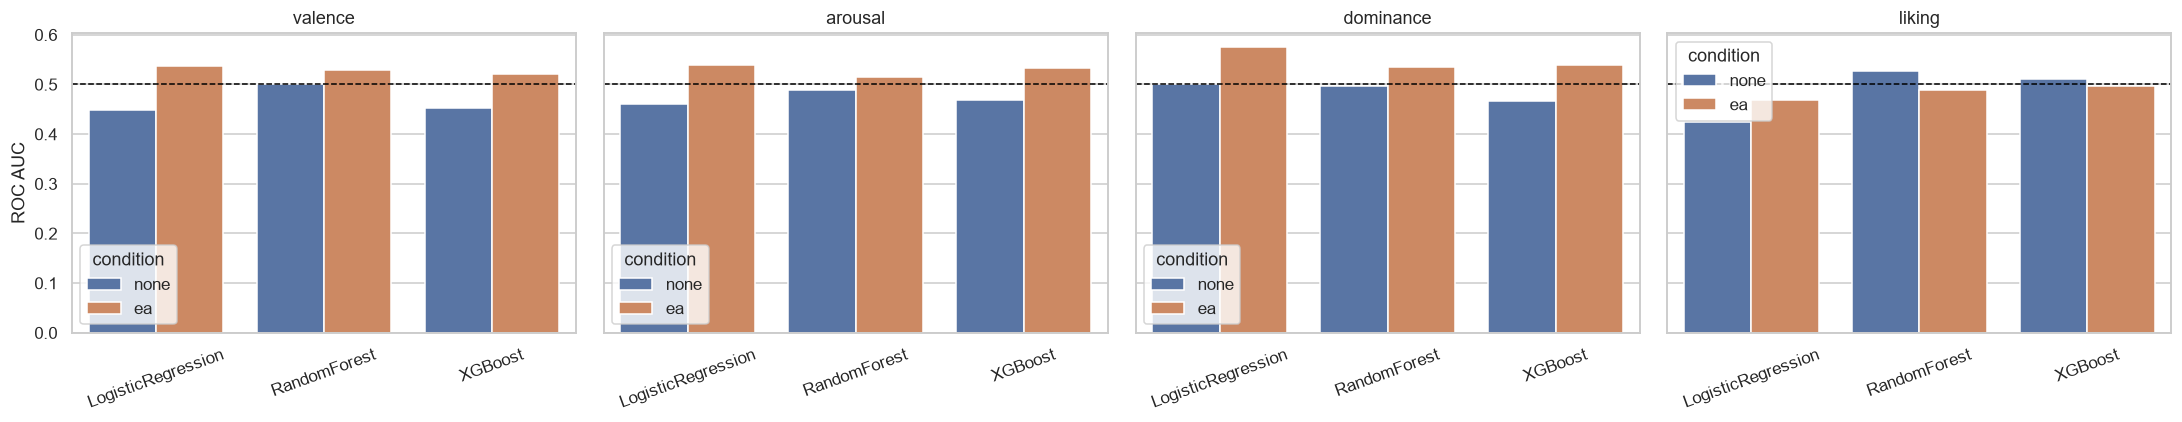

EA vs. no alignment -- mean delta AUC across all 12 task/model combos: +0.0443
Positive deltas: 10/12
Best single delta: +0.0873 (('valence', 'LogisticRegression'))
Worst single delta: -0.0384 (('liking', 'RandomForest'))


In [30]:
ea = pd.read_csv(TABLES_DIR / "track_a_riemannian_alignment.csv")
display(ea.pivot_table(index=["task", "model"], columns="condition", values="roc_auc_mean")
        .assign(delta_auc=lambda d: d["ea"] - d["none"])
        .style.format("{:.4f}"))

fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(5 * len(TASK_ORDER), 4), sharey=True)
for ax, task in zip(axes, TASK_ORDER):
    sub = ea[ea.task == task]
    sns.barplot(data=sub, x="model", y="roc_auc_mean", hue="condition", ax=ax)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(task); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20)
    ax.set_ylabel("ROC AUC" if task == TASK_ORDER[0] else "")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_a_riemannian_alignment_auc.png", dpi=150, bbox_inches="tight")
plt.show()

delta = (ea.pivot_table(index=["task", "model"], columns="condition", values="roc_auc_mean")
         .assign(delta=lambda d: d["ea"] - d["none"]))
print(f"EA vs. no alignment -- mean delta AUC across all 12 task/model combos: {delta['delta'].mean():+.4f}")
print(f"Positive deltas: {(delta['delta'] > 0).sum()}/12")
print(f"Best single delta: {delta['delta'].max():+.4f} ({delta['delta'].idxmax()})")
print(f"Worst single delta: {delta['delta'].min():+.4f} ({delta['delta'].idxmin()})")


**Actual result: the strongest, most consistent effect of any alignment
technique tried in this project.** Mean AUC delta across all 12 task/model
combinations is **+0.044** (vs. CORAL's +0.0059 in 16.2) -- **10 of 12**
combinations improved (vs. CORAL's 8/12), and unlike CORAL the sign is
consistent *within* three of the four tasks: valence (+0.087, +0.027, +0.069
across LR/RF/XGBoost), arousal (+0.078, +0.027, +0.065), and dominance
(+0.074, +0.038, +0.073) all improved for every model. Only liking is mixed
(LogisticRegression +0.045, but RandomForest -0.038 and XGBoost -0.014).

This is the best single AUC-delta result in the entire notebook so far --
but it is still a modest absolute improvement (best post-alignment AUCs
land around 0.53-0.58, not a qualitative jump to a strong classifier), and it
operates on the raw-signal covariance structure rather than the
already-extracted feature space CORAL touches, which is a plausible reason
the two techniques behave so differently despite both being "alignment."
It is worth testing whether combining EA (raw-signal-level) with CORAL
(feature-level) compounds further -- flagged as a natural next step, not run
here.

### 17.2 Self-supervised (TFR-style) pretraining

`scripts/track_b_ssl_pretrain.py` pretrains EEGNet's conv trunk with a
label-free pretext task (predict each window's own 32-channel x 4-band
log-band-power from the raw time-domain signal, MSE loss, training-fold
subjects only), then fine-tunes the whole network end-to-end on the labeled
task, compared against an identically-trained "scratch" (randomly
initialized) EEGNet. Motivated by `Cascaded Self-Supervised Learning for Subject-Independent EEG-Based Emotion Recognition.pdf`, the only paper in the whole
literature review evaluated LOSO on DEAP itself while beating DA
baselines.

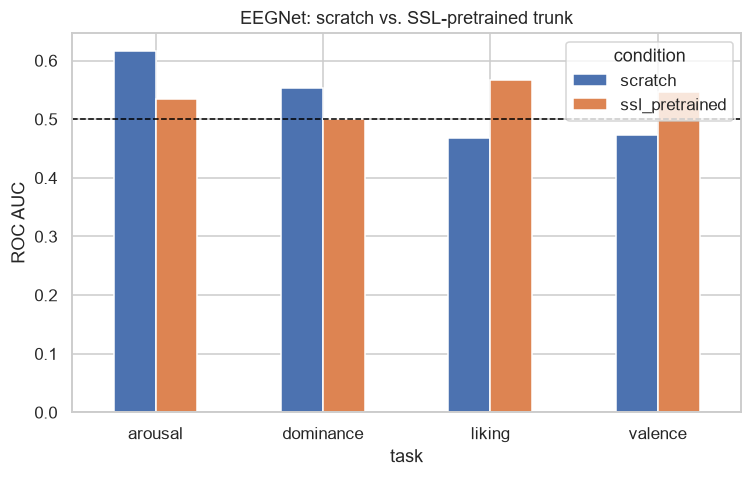

SSL-pretrained vs. scratch, ROC-AUC delta per task:
  arousal    scratch=0.616  ssl=0.534  delta=-0.082
  dominance  scratch=0.552  ssl=0.500  delta=-0.053
  liking     scratch=0.467  ssl=0.567  delta=+0.100
  valence    scratch=0.474  ssl=0.547  delta=+0.074

Mean delta across tasks: +0.0097


In [31]:
ssl = pd.read_csv(TABLES_DIR / "track_b_ssl_pretrain.csv")
display(ssl.pivot(index="task", columns="condition", values=["accuracy", "f1_macro", "roc_auc"])
        .style.format("{:.4f}"))

fig, ax = plt.subplots(figsize=(7, 4.5))
piv = ssl.pivot(index="task", columns="condition", values="roc_auc")[["scratch", "ssl_pretrained"]]
piv.plot(kind="bar", ax=ax)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_ylabel("ROC AUC"); ax.set_title("EEGNet: scratch vs. SSL-pretrained trunk")
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_b_ssl_pretrain_auc.png", dpi=150, bbox_inches="tight")
plt.show()

delta = piv["ssl_pretrained"] - piv["scratch"]
print("SSL-pretrained vs. scratch, ROC-AUC delta per task:")
for task, d in delta.items():
    print(f"  {task:<10} scratch={piv.loc[task, 'scratch']:.3f}  ssl={piv.loc[task, 'ssl_pretrained']:.3f}  delta={d:+.3f}")
print(f"\nMean delta across tasks: {delta.mean():+.4f}")


**Actual result: a bimodal, task-split pattern, not a clean win.** Valence
(+0.074) and liking (+0.100) improved meaningfully; arousal (-0.082) and
dominance (-0.053) got worse. Mean delta across tasks is a small +0.010 --
masking the fact that no task landed close to zero. This is the *same*
two-tasks-up/two-tasks-down split seen in section 16.3's DANN result, and it
recurs again in 17.3 and 17.4 below -- see 17.6 for the cross-cutting pattern
this suggests. The pretext task itself trained fine (MSE dropped from 0.64 to
0.27 over 15 epochs on standardized band-power targets), so this is not a
pretraining-failed-to-converge artifact -- the pretrained trunk successfully
learned *something* about spectral structure, it just was not uniformly
useful as a fine-tuning initialization across all four label definitions.

### 17.3 AUC-margin training loss

`scripts/track_b_auc_maximization.py` replaces `nn.CrossEntropyLoss` with a
mini-batch pairwise squared-hinge AUC surrogate
(`mean_{i in pos, j in neg} max(0, margin - (s_i - s_j))^2`, a simplified,
self-contained version of the Ying et al.-style AUC-margin idea `Electroencephalogram Emotion Recognition via AUC Maximization.pdf`
builds its full saddle-point solver around), everything else (model, split,
seed) held identical to the cross-entropy baseline.

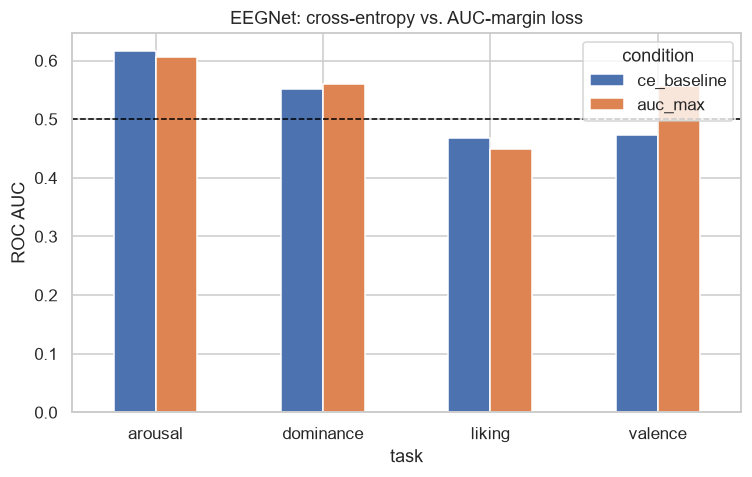

AUC-margin vs. cross-entropy, ROC-AUC delta per task:
  arousal    ce=0.616  auc_max=0.606  delta=-0.010
  dominance  ce=0.552  auc_max=0.560  delta=+0.008
  liking     ce=0.467  auc_max=0.450  delta=-0.017
  valence    ce=0.474  auc_max=0.557  delta=+0.083

Mean delta across tasks: +0.0159


In [32]:
aucmax = pd.read_csv(TABLES_DIR / "track_b_auc_maximization.csv")
display(aucmax.pivot(index="task", columns="condition", values=["accuracy", "f1_macro", "roc_auc"])
        .style.format("{:.4f}"))

fig, ax = plt.subplots(figsize=(7, 4.5))
piv = aucmax.pivot(index="task", columns="condition", values="roc_auc")[["ce_baseline", "auc_max"]]
piv.plot(kind="bar", ax=ax)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_ylabel("ROC AUC"); ax.set_title("EEGNet: cross-entropy vs. AUC-margin loss")
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_b_auc_maximization_auc.png", dpi=150, bbox_inches="tight")
plt.show()

delta = piv["auc_max"] - piv["ce_baseline"]
print("AUC-margin vs. cross-entropy, ROC-AUC delta per task:")
for task, d in delta.items():
    print(f"  {task:<10} ce={piv.loc[task, 'ce_baseline']:.3f}  auc_max={piv.loc[task, 'auc_max']:.3f}  delta={d:+.3f}")
print(f"\nMean delta across tasks: {delta.mean():+.4f}")


**Actual result: a real, mechanistically-explainable gain for valence, small
mixed effects elsewhere.** Valence improved the most of any single result in
17.2-17.4 (+0.083, AUC 0.474 -> 0.557) -- and the *mechanism* is visible in the
raw numbers: the cross-entropy baseline for valence had accuracy 0.835 with
AUC only 0.474, the classic signature of a classifier collapsing toward the
majority class under imbalance (high accuracy, chance-or-below AUC); the
AUC-margin loss produced a far more balanced classifier (accuracy 0.507, AUC
0.557) precisely because it is insensitive to that kind of imbalance by
construction. Dominance improved slightly (+0.008); arousal (-0.010) and
liking (-0.018) were both small, likely-noise-level regressions. Mean delta
+0.016. This is the one intervention in section 17 with a clear, understood
reason *why* it helped where it helped, rather than an unexplained task
split.

### 17.4 AdaBN test-time adaptation

`scripts/track_b_test_time_adaptation.py` recomputes every BatchNorm layer's
running statistics using ONLY a held-out test subject's own unlabeled
windows (no gradient updates, no labels), per subject, then evaluates that
subject with the adapted statistics -- the cheapest member of the source-free
UDA family `Towards Practical Emotion Recognition - An Unsupervised Source-Free Approach for EEG Domain Adaptation.pdf` surveys, compared against the same trained baseline
evaluated with its original (training-population) BatchNorm statistics.

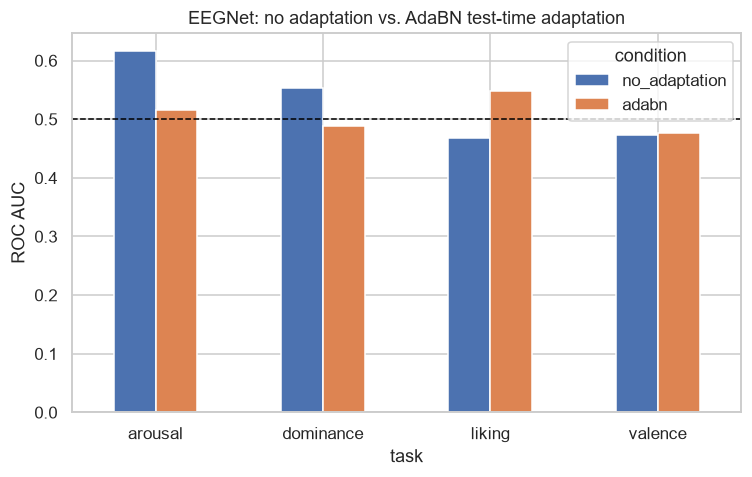

AdaBN vs. no adaptation, ROC-AUC delta per task:
  arousal    no_adapt=0.616  adabn=0.515  delta=-0.101
  dominance  no_adapt=0.552  adabn=0.489  delta=-0.063
  liking     no_adapt=0.467  adabn=0.549  delta=+0.082
  valence    no_adapt=0.474  adabn=0.476  delta=+0.002

Mean delta across tasks: -0.0201


In [33]:
adabn = pd.read_csv(TABLES_DIR / "track_b_test_time_adaptation.csv")
display(adabn.pivot(index="task", columns="condition", values=["accuracy", "f1_macro", "roc_auc"])
        .style.format("{:.4f}"))

fig, ax = plt.subplots(figsize=(7, 4.5))
piv = adabn.pivot(index="task", columns="condition", values="roc_auc")[["no_adaptation", "adabn"]]
piv.plot(kind="bar", ax=ax)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_ylabel("ROC AUC"); ax.set_title("EEGNet: no adaptation vs. AdaBN test-time adaptation")
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_b_test_time_adaptation_auc.png", dpi=150, bbox_inches="tight")
plt.show()

delta = piv["adabn"] - piv["no_adaptation"]
print("AdaBN vs. no adaptation, ROC-AUC delta per task:")
for task, d in delta.items():
    print(f"  {task:<10} no_adapt={piv.loc[task, 'no_adaptation']:.3f}  adabn={piv.loc[task, 'adabn']:.3f}  delta={d:+.3f}")
print(f"\nMean delta across tasks: {delta.mean():+.4f}")


**Actual result: net negative, and the clearest instance of the
arousal/dominance-vs-valence/liking split in this section.** Arousal (-0.101)
and dominance (-0.063) got substantially worse; liking improved (+0.082) and
valence was flat (+0.002). Mean delta -0.020 -- the only clearly net-negative
intervention in section 17. Recomputing BatchNorm statistics per-subject
evidently discards some of the training-population structure that arousal's
and dominance's baselines (the two strongest baseline AUCs across all of
section 17's Track B experiments, ~0.55-0.62) were relying on, without
replacing it with anything better.

### 17.5 SHAP diagnostic: plausible signal or noise?

`scripts/track_a_shap_diagnostic.py` fits XGBoost on the Full feature set (one
representative GroupKFold fold per task) and computes SHAP values on the held-out
fold, aggregated by feature family (DE, Hjorth, FAA, Connectivity) and reported
per individual feature. This is a diagnostic, not an intervention -- it asks
whether the (weak) signal these near-chance models find looks
neurophysiologically plausible or noise-like, motivated by
`Enhancing EEG-Based Emotion Detection with Hybrid Models - Insights from DEAP Dataset Applications.pdf`.

In [34]:
shap_df = pd.read_csv(TABLES_DIR / "track_a_shap_diagnostic.csv")
family_share = shap_df[shap_df.feature.str.startswith("__family_share__")].copy()
family_share["family"] = family_share.feature.str.replace("__family_share__", "", regex=False)
display(family_share.pivot(index="task", columns="family", values="mean_abs_shap").style.format("{:.1%}"))

top_features = shap_df[~shap_df.feature.str.startswith("__family_share__")]
for task in TASK_ORDER:
    print(f"\n[{task}] top 5 features by mean |SHAP|:")
    print(top_features[top_features.task == task].head(5)[["feature", "family", "mean_abs_shap"]]
          .to_string(index=False))


family,Connectivity,DE,FAA,Hjorth
task,,,,
arousal,21.8%,51.8%,3.4%,23.0%
dominance,23.8%,47.2%,6.1%,22.9%
liking,23.1%,46.8%,4.4%,25.7%
valence,24.2%,50.7%,3.7%,21.5%



[valence] top 5 features by mean |SHAP|:
     feature family  mean_abs_shap
  de_beta_P4     DE       0.168300
 de_gamma_Pz     DE       0.135714
de_gamma_CP5     DE       0.085707
de_gamma_Fp2     DE       0.083569
de_gamma_FC2     DE       0.082879

[arousal] top 5 features by mean |SHAP|:
         feature       family  mean_abs_shap
    de_gamma_FC2           DE       0.261224
     de_beta_FC1           DE       0.129659
     de_gamma_C3           DE       0.117562
plv_beta_Fp1-Fp2 Connectivity       0.111422
     de_gamma_T7           DE       0.110925

[dominance] top 5 features by mean |SHAP|:
       feature       family  mean_abs_shap
plv_beta_F3-O1 Connectivity       0.101926
   de_gamma_C4           DE       0.088333
  de_gamma_CP6           DE       0.079462
         F3-F4          FAA       0.074096
  de_gamma_AF4           DE       0.072126

[liking] top 5 features by mean |SHAP|:
            feature       family  mean_abs_shap
       de_gamma_FC2           DE       0.1300

**Actual result: importance is spread across families roughly in
proportion to how many features each family contributes, with two mild but
consistent departures.** Of the 295 Full-set features, DE contributes 43.4% (128),
Hjorth 32.5% (96), Connectivity 19.3% (57), FAA 4.7% (14). Across all four
tasks, DE's actual SHAP share (47-52%) and Connectivity's (22-24%) both sit
somewhat *above* their feature-count share, while Hjorth's (21-26%) sits
*below* -- a mild, consistent preference for spectral-power and
cross-channel-connectivity features over single-channel signal-complexity
features, not a random/noise-like pattern.

Notably, **frontal/hemispheric alpha asymmetry (FAA) -- the one feature family
built specifically around a named, hypothesis-driven neurophysiological
mechanism (Davidson-style approach/withdrawal asymmetry) -- carries the
*smallest* share of importance in every task (3.4-6.1%)**, roughly at or
below its 4.7% feature-count baseline. Top individual features skew toward DE
gamma/beta power at specific channels (`de_gamma_FC2` is the single top
feature for both arousal and liking) and one connectivity feature
(`plv_beta_F3-O1` for dominance), not FAA. This means the near-chance
classifiers are not obviously leaning on the literature's classic asymmetry
hypothesis, nor are they picking up nothing at all (importance is not spread
uniformly/randomly) -- the honest reading is that whatever weak, mostly
unhelpful structure these models exploit is spread across generic spectral
power and connectivity, in roughly the proportions those families are
represented in the feature set, rather than concentrated on anything
specifically meaningful.

### 17.6 Summary: what section 17 added

- **Euclidean Alignment (17.1) is the strongest single result in this
  notebook**: +0.044 mean AUC delta, 10/12 task/model combinations improved,
  and unlike every other alignment/adaptation technique tried (CORAL in 16.2,
  DANN in 16.3, AdaBN in 17.4), the improvement is *consistent in sign* for
  three of the four tasks (valence, arousal, dominance all positive for every
  one of the 3 models tested). Still modest in absolute terms (~0.53-0.58 AUC,
  not a qualitative leap), but the most reproducible positive signal found
  across sections 16-17.
- **A recurring task split, not four independent coin flips**: DANN (16.3),
  SSL pretraining (17.2), and AdaBN (17.4) all show the *same* pattern --
  valence and liking improve, arousal and dominance get *worse* -- across
  three unrelated mechanisms (adversarial training, self-supervised
  pretraining, test-time BatchNorm recalibration). Arousal and dominance are
  also the two tasks with the strongest baseline AUCs in these same Track B
  experiments (arousal ~0.55-0.62, dominance ~0.55). The natural reading: these
  three interventions all perturb the *learned representation* in some way,
  and whatever fold-specific structure the untouched baseline had already
  found for arousal/dominance is more fragile to that perturbation than
  valence/liking's much weaker baseline representations are. AUC-margin loss
  (17.3) is the exception with a clear, understood mechanism (fixing
  class-imbalance collapse for valence specifically) rather than fitting this
  representation-perturbation pattern, and it is also the only Track B
  intervention here that is a training-*loss* change rather than a
  representation/architecture/statistics change -- consistent with the
  above explanation.
- **SHAP (17.5) adds an interpretability finding, not an AUC result**: feature
  importance is spread across families roughly proportional to feature count,
  with DE and Connectivity mildly over-represented and Hjorth
  under-represented -- and, notably, the one family built around a specific
  named neurophysiological hypothesis (frontal/hemispheric alpha asymmetry)
  carries the *least* importance of all four families in every task. Neither
  a plausible concentrated signal nor pure noise -- a diffuse, generic
  spectral/connectivity pattern.
- **Practical bottom line for the paper**: of five previously-deferred,
  literature-backed techniques, one (Euclidean Alignment) gives a real,
  reproducible, if modest, AUC improvement; one (AUC-margin loss) gives a
  smaller, mechanistically-understood improvement specific to a
  class-imbalance failure mode; two (SSL pretraining, AdaBN) are net-neutral-
  to-negative on average but reveal the same task-dependent instability
  pattern DANN showed; and the SHAP diagnostic shows the underlying signal is
  diffuse rather than concentrated on any specific neurophysiological marker.
  This does not overturn sections 1-16's central finding that subject-
  independent AUC stays far below what would be practically useful -- but
  Euclidean Alignment in particular is now a concrete, evidence-backed
  candidate worth combining with the existing Full feature set and/or with
  CORAL in future work, rather than another ruled-out hypothesis.
- Full attribution -- what was taken from each of the five source papers, and
  exactly how each maps to the scripts above -- is in
  `D:/EEG/papers_EEG/literature_log.txt` ("BATCH 6").

## 18. Does CORAL stack on top of Euclidean Alignment?

17.1 found Euclidean Alignment (EA, raw-signal per-subject covariance
whitening) to be the strongest single alignment result in the project
(+0.044 mean AUC delta). 16.2 found CORAL (per-fold feature-level alignment)
gives a much smaller, inconsistent-sign effect (+0.0059). Both scripts'
docstrings flagged combining the two as a natural next step -- they touch
different parts of the pipeline (EA: upstream, raw-channel, per-subject;
CORAL: downstream, per-fold, feature-level) and are not obviously redundant.
`scripts/track_a_ea_coral_stacked.py` tests four conditions on the same
DE-only feature set as 17.1 (GroupKFold(5), 3 models, 4 tasks): `none`,
`coral` alone, `ea` alone, and `ea_coral` (EA first, then CORAL on the
resulting per-fold split).

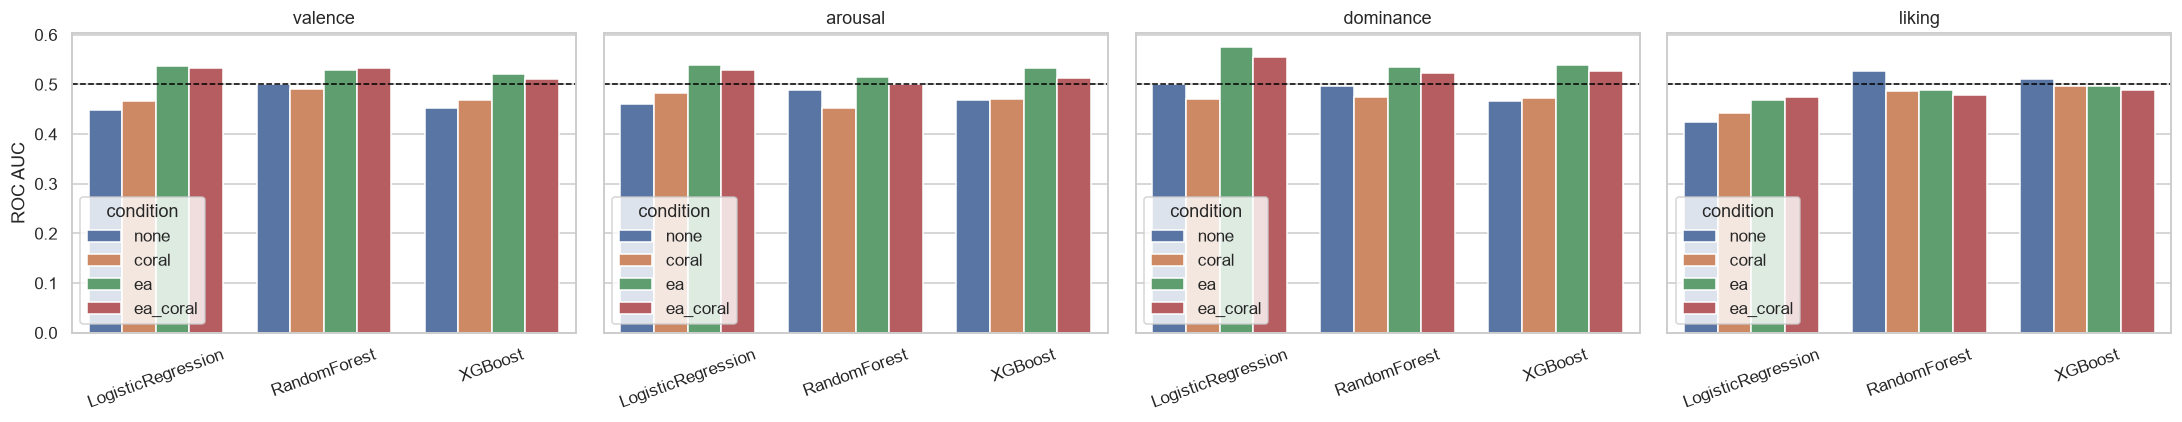

Mean AUC by condition (averaged across all 12 task/model combos):
condition
ea          0.5232
ea_coral    0.5138
none        0.4789
coral       0.4731
Name: roc_auc_mean, dtype: float64

ea_coral beats ea alone in 2/12 combos (mean delta -0.0093)


In [35]:
stack = pd.read_csv(TABLES_DIR / "track_a_ea_coral_stacked.csv")
piv = stack.pivot_table(index=["task", "model"], columns="condition", values="roc_auc_mean")
piv = piv[["none", "coral", "ea", "ea_coral"]]
piv["stack_vs_ea"] = piv["ea_coral"] - piv["ea"]
display(piv.style.format("{:.4f}"))

fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(5 * len(TASK_ORDER), 4), sharey=True)
for ax, task in zip(axes, TASK_ORDER):
    sub = stack[stack.task == task]
    sns.barplot(data=sub, x="model", y="roc_auc_mean", hue="condition", ax=ax,
                hue_order=["none", "coral", "ea", "ea_coral"])
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(task); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20)
    ax.set_ylabel("ROC AUC" if task == TASK_ORDER[0] else "")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "track_a_ea_coral_stacked_auc.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mean AUC by condition (averaged across all 12 task/model combos):")
print(stack.groupby("condition")["roc_auc_mean"].mean().round(4).sort_values(ascending=False))
print(f"\nea_coral beats ea alone in {(piv['stack_vs_ea'] > 0).sum()}/12 combos "
      f"(mean delta {piv['stack_vs_ea'].mean():+.4f})")


In [36]:

# ----- Quick-run switch: True = fast smoke test on a few subjects/epochs -----
QUICK_RUN = False
FORCE_REBUILD_CACHE = False   # set True to ignore cached windows/features and recompute

DATA_DIR = Path(r"D:/EEG/deap-dataset/data_preprocessed_python")
CACHE_DIR = Path(r"D:/EEG/processed_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR = Path(r"D:/EEG/results")
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

FS = 128                       # Hz, DEAP preprocessed sampling rate
N_EEG_CHANNELS = 32            # first 32 of the 40 channels are EEG
BASELINE_SEC = 3
BASELINE_SAMPLES = BASELINE_SEC * FS          # 384
TRIAL_SEC = 60
TRIAL_SAMPLES = TRIAL_SEC * FS                # 7680

WINDOW_SEC = 4
WINDOW_SAMPLES = WINDOW_SEC * FS              # 512  -> 15 non-overlapping windows / trial

BANDS = {"theta": (4, 8), "alpha": (8, 13), "beta": (13, 30), "gamma": (30, 45)}
BAND_ORDER = ["theta", "alpha", "beta", "gamma"]

LABEL_THRESHOLD = 5.0          # DEAP convention: rating > 5 -> "high" (1), else "low" (0)

ALL_SUBJECT_IDS = list(range(1, 33))
SUBJECT_IDS = ALL_SUBJECT_IDS if not QUICK_RUN else ALL_SUBJECT_IDS[:8]

N_EPOCHS = 40 if not QUICK_RUN else 5
BATCH_SIZE = 128
PATIENCE = 8 if not QUICK_RUN else 3

# Standard DEAP 32-channel (10-20 system) order, used for TSception's hemisphere pairing.
DEAP_CHANNELS = [
    "Fp1","AF3","F3","F7","FC5","FC1","C3","T7","CP5","CP1","P3","P7","PO3","O1","Oz","Pz",
    "Fp2","AF4","Fz","F4","F8","FC6","FC2","Cz","C4","T8","CP6","CP2","P4","P8","PO4","O2",
]
LEFT_RIGHT_PAIRS = [
    ("Fp1","Fp2"),("AF3","AF4"),("F3","F4"),("F7","F8"),("FC5","FC6"),("FC1","FC2"),
    ("C3","C4"),("T7","T8"),("CP5","CP6"),("CP1","CP2"),("P3","P4"),("P7","P8"),
    ("PO3","PO4"),("O1","O2"),
]
LEFT_IDX = [DEAP_CHANNELS.index(l) for l, r in LEFT_RIGHT_PAIRS]
RIGHT_IDX = [DEAP_CHANNELS.index(r) for l, r in LEFT_RIGHT_PAIRS]

print(f"Subjects used: {len(SUBJECT_IDS)} | window = {WINDOW_SEC}s ({WINDOW_SAMPLES} samples) "
      f"| windows/trial = {TRIAL_SAMPLES // WINDOW_SAMPLES}")


Subjects used: 32 | window = 4s (512 samples) | windows/trial = 15


In [37]:

import os, sys, time, pickle, warnings, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, sosfiltfilt

from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix

from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
XGB_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# Fixed categorical palette, one color per model, reused consistently across every plot.
MODEL_ORDER = ["LogisticRegression", "kNN", "RandomForest", "SVM-RBF", "XGBoost", "MLP",
               "ShallowConvNet", "EEGNet", "CNN-LSTM", "TSception"]
PALETTE = dict(zip(MODEL_ORDER, sns.color_palette("colorblind", len(MODEL_ORDER))))

# DEAP labels array columns, in order: [valence, arousal, dominance, liking]
LABEL_COLUMNS = {"valence": 0, "arousal": 1, "dominance": 2, "liking": 3}
TASK_ORDER = list(LABEL_COLUMNS.keys())


Torch: 2.6.0+cu124 | CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti
